### Importing of libraries

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
import sqlite3
%matplotlib inline
import math
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
import warnings
warnings.filterwarnings('ignore')

### Data Import

In [4]:
db_path = r"E:\Machine Learning Research\DataModelling\IDA_Data.db"  # <-- change this to your actual .db file path
table_name = "IDA_Data"                    # <-- your table name

conn = sqlite3.connect(db_path)
df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
conn.close()

# === Display===
# print(df.shape)
# print(list(df.columns))
# === Optionally, show first few rows ===
# print(InputHeads)
# print(OutputHeads)
# print("\nFirst 5 rows:")
# print(df.columns)
# df.columns

AllColumns = ['id', 'Earthquake', 'ScaleFactor', 'Building', 'BaseCondition', 'ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-', 'Plan-area', 'Seismic-weight', 
              'StiffnessX_Story5', 'StiffnessX_Story4', 'StiffnessX_Story3', 'StiffnessX_Story2', 'StiffnessX_Story1', 'StiffnessX_Total', 'Layer1_FrictionA', 'Layer1_G_kPa', 
              'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion', 'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion',
              'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 'PGA', 'Magnitude', 'Mechanism', 'Rjb', 'Rrup', 'Vs30', 'cav_gs', 
              'scav_gs', 'bcav_gs', 'arias_mps', 'husid_s', 'spi_mps', 'hous_m', 'maxacceleration_mps2', 'maxvelocity_mps', 'maxdisplacement_m', 'maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps', 
              'Fundamental_Period', 'Drift-X_Level-1', 'Drift-X_Level-2', 'Drift-X_Level-3', 'Drift-X_Level-4', 'Drift-X_Level-5', 'Drift-X_Level-6', 'Drift-Y_Level-1', 'Drift-Y_Level-2',
              'Drift-Y_Level-3', 'Drift-Y_Level-4', 'Drift-Y_Level-5', 'Drift-Y_Level-6', 'Displacement-X_Level-1', 'Displacement-X_Level-2', 'Displacement-X_Level-3', 'Displacement-X_Level-4',
              'Displacement-X_Level-5', 'Displacement-X_Level-6', 'Displacement-Y_Level-1', 'Displacement-Y_Level-2', 'Displacement-Y_Level-3', 'Displacement-Y_Level-4', 'Displacement-Y_Level-5',
              'Displacement-Y_Level-6', 'Reaction-Force-X_Level-1', 'Reaction-Force-X_Level-2', 'Reaction-Force-X_Level-3', 'Reaction-Force-X_Level-4', 'Reaction-Force-X_Level-5', 'Reaction-Force-X_Level-6', 
              'Reaction-Force-Y_Level-1', 'Reaction-Force-Y_Level-2', 'Reaction-Force-Y_Level-3', 'Reaction-Force-Y_Level-4', 'Reaction-Force-Y_Level-5', 'Reaction-Force-Y_Level-6', 'Reaction-Moment-X_Level-1',
              'Reaction-Moment-X_Level-2', 'Reaction-Moment-X_Level-3', 'Reaction-Moment-X_Level-4', 'Reaction-Moment-X_Level-5', 'Reaction-Moment-X_Level-6', 'Reaction-Moment-Y_Level-1',
              'Reaction-Moment-Y_Level-2', 'Reaction-Moment-Y_Level-3', 'Reaction-Moment-Y_Level-4', 'Reaction-Moment-Y_Level-5', 'Reaction-Moment-Y_Level-6', 'Rotation-X_Level-1', 'Rotation-X_Level-2',
              'Rotation-X_Level-3', 'Rotation-X_Level-4', 'Rotation-X_Level-5', 'Rotation-X_Level-6', 'Rotation-Y_Level-1', 'Rotation-Y_Level-2', 'Rotation-Y_Level-3', 'Rotation-Y_Level-4', 'Rotation-Y_Level-5',
              'Rotation-Y_Level-6', 'Rotation-Z_Level-1', 'Rotation-Z_Level-2', 'Rotation-Z_Level-3', 'Rotation-Z_Level-4', 'Rotation-Z_Level-5', 'Rotation-Z_Level-6', 'Torsional-Irregularity-Ratio_Level-1',
              'Torsional-Irregularity-Ratio_Level-2', 'Torsional-Irregularity-Ratio_Level-3', 'Torsional-Irregularity-Ratio_Level-4', 'Torsional-Irregularity-Ratio_Level-5', 'Torsional-Irregularity-Ratio_Level-6',
              'Max-Uplift_Level-1', 'Max-Uplift-Point_Level-1', 'Max-Settlement_Level-1', 'Max-Settlement-Point_Level-1', 'Max-Pseudo-Time_Level-1']

### Data Processing

In [5]:
def dataPreparation(DoNormalize = True,Z_ScoreScaler = True    ,        ModelSet = 2     ,includeCategoricalData = False  ):
    
    # Creating of the PeakGroundAcceleration column on the database by product of ScaleFactor and MaximumAcceleration of the data
    df['maxacceleration_mps2'] = pd.to_numeric(df['maxacceleration_mps2'], errors='coerce')
    df['ScaleFactor'] = pd.to_numeric(df['ScaleFactor'], errors='coerce')
    df['PeakGroundAcceleration'] = df['maxacceleration_mps2'] * df['ScaleFactor']
    
    #Creating of the Prediction column as Max drift of the all levels merger in single column as below
    drift_cols = [    'Drift-X_Level-1', 'Drift-X_Level-2', 'Drift-X_Level-3',    'Drift-X_Level-4', 'Drift-X_Level-5', 'Drift-X_Level-6']
    df[drift_cols] = df[drift_cols].apply(pd.to_numeric, errors='coerce')
    df['Max_Drift_X'] = df[drift_cols].max(axis=1)
    
    # Check for any NaNs that might have appeared due to conversion issues
    # print(df[['maxacceleration_mps2', 'ScaleFactor', 'PeakGroundAcceleration']].sample(50))
    # print("Number of NaNs in new column:", df['PeakGroundAcceleration'].isna().sum())
    
    InputHeadsAvailableAll = ['Earthquake', 'ScaleFactor', 'Building', 'BaseCondition', 'ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-', 'Plan-area', 'Seismic-weight', 
                  'StiffnessX_Story5', 'StiffnessX_Story4', 'StiffnessX_Story3', 'StiffnessX_Story2', 'StiffnessX_Story1', 'StiffnessX_Total', 
                  'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
                  'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
                  'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 
                  'PGA', 'Magnitude', 'Mechanism', 'Rjb', 'Rrup', 'Vs30', 'cav_gs', 'scav_gs', 'bcav_gs', 'arias_mps', 'husid_s', 'spi_mps', 'hous_m', 'maxacceleration_mps2',
                  'maxvelocity_mps', 'maxdisplacement_m', 'maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps', 
                  'Fundamental_Period']
    InputHeadsSelected = ['ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-',
                   'StiffnessX_Total', 'Plan-area', 'Seismic-weight', 
                  'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
                  'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
                  'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion',                           
                  "PeakGroundAcceleration", 'Magnitude', 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',  'cav_gs', 
                             'Fundamental_Period']
    # InputHeadsSelected = InputHeadsAvailableAll

    
    #Best performer for the fixedbase and displacement output
                   # "PeakGroundAcceleration", 'Magnitude', 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',  'cav_gs', 
                   #           'Fundamental_Period']
    #Best performer for the maximum drift along X with r2 as 89.36 (Donot include  'Plan-area', 'Seismic-weight', 'StiffnessX_Total', as they donot produce any effect and only add burden to model)
    # InputHeadsSelected = ['ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-',
                   
    #               'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
    #               'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
    #               'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 
                          
    #               "PeakGroundAcceleration", 'Magnitude', 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',  'cav_gs', 
    #                          'Fundamental_Period']
    #Best performer for the fixed and output as Reaction-Force-X_Level-1:  r2 as 0.95 max with 15 features
    # InputHeadsSelected = ['Earthquake', 'Building', 'Fundamental_Period',  'ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx',
    #               'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
    #               'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
    #               'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 
    #                "PeakGroundAcceleration", 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',
    #                         ]
    #For soil analysis take Rup, Vs30... Use maxacceleration_mps2 that represents the pga value of site and for the building specific analysis ie performance
    # Levels measurement take PSA, PSV and PSD values over the peac acc peak vel and peak disp and so on 
    #Final selected features (9): ['ScaleFactor', 'Vs30', 'cav_gs', 'arias_mps', 'husid_s', 'hous_m', 'maxvelocity_mps', 'maxdisplacement_m', 'maxpsd_cmps']
    
    
    
    #_______________________________________________________________________________________________________________________________________________________________Processing starts from here
    if ModelSet == 1 :
        InputHeads = [x for x in InputHeadsSelected if not x.startswith("Layer")] 
    elif ModelSet == 3:
        InputHeads = [x for x in InputHeadsSelected if not x.startswith("Layer")]
        InputHeads = InputHeads + ["BaseCondition"]
    else:
        InputHeads = InputHeadsSelected
    # OutputHeads = ['Displacement-X_Level-5']
    # OutputHeads = ["Reaction-Force-X_Level-1"]
    OutputHeads = ['Max_Drift_X']
    
    # df[InputHeads].info
    
    ####__________________________________________________________________________________________________________________________________Data selection 
    
    # Extract all the data from the fixed base conditions only
    if ModelSet == 1:
        df_fixed = df[df['BaseCondition'] == 'Fixed']
    elif ModelSet == 2:
        df_fixed = df[df['BaseCondition'] != 'Fixed']
    else:
        df_fixed = df[df['BaseCondition'].isin(['Fixed', 'Soft', 'Medium', 'Hard'])]
        
    
    #Convert all the data in database to numerical format
    if includeCategoricalData:
        df_numeric = df_fixed.copy()
        for col in df_numeric.columns:
            df_numeric[col] = pd.to_numeric(df_numeric[col], errors='ignore')
    else:
        df_numeric = df_fixed.apply(pd.to_numeric, errors='coerce')
        df_numeric.shape
    # df_numeric.head
    
    ##Extract the data if the scale factor is less than or equal to 1 only
    if ModelSet != 1:
        df_numeric = df_numeric[df_numeric['ScaleFactor'] <= 1]
    df_numeric = df_numeric[df_numeric['ScaleFactor'] <= 1]
    
    #Removing all the white spaces on the column titles
    df_numeric.columns = df_numeric.columns.str.replace(" ", "_")

    ####__________________________________________________________________________________________________________________________________Encoding of data
    # # Normalize for the data of the features as seismic weights, and so on
    features_to_normalize = [x for x in InputHeads
                             if pd.api.types.is_numeric_dtype(df_numeric[x])]
    
    
    #One hot encoding of the categorical data if user set it to include in the model
    if includeCategoricalData:
        Catcolumns =  [x for x in InputHeads if x not in features_to_normalize]
        # print(Catcolumns)

        if Catcolumns:
            data_toEncode = df_numeric[Catcolumns]     
            CatDataEncoded = pd.get_dummies(data_toEncode, columns = Catcolumns,  dtype=float)
            df_numeric = df_numeric.drop(columns=Catcolumns)

        
            if df_numeric.shape[0] == CatDataEncoded.shape[0]:
                InputHeads = InputHeads + list(CatDataEncoded.columns)
                df_numeric = pd.concat([df_numeric, CatDataEncoded], axis=1)

            else: 
                raise
    

    
    ## Converts all the data to the numeric even to that of hot encoded as they are in float
    df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')
        
    
    ####__________________________________________________________________________________________________________________________________Missing Data Handling
    df_numeric =df_numeric.dropna(axis=1, how='all')             #Dropping for all the columns (axis = 1) if it has all values of NaN
    
    #### Show only columns that actually contain NaN
    # nan_counts = df_numeric.isna().sum()
    # nan_counts = nan_counts[nan_counts > 0]
    # print("Columns containing NaN values (column: count):")
    # print(nan_counts)
    
    # nan_rows = df_numeric[df_numeric.isna().any(axis=1)]
    # print("Rows containing NaN values:")
    # print(nan_rows)
    
    df_numeric = df_numeric.apply(lambda col: col.fillna(col.median()) if col.dtype != 'object' else col)   #For any value other than object if the data is shown as missing then it fills up with the median of that column

    # nan_counts = df_numeric.isna().sum()
    # nan_counts = nan_counts[nan_counts > 0]
    # print("Columns containing NaN values (column: count):")
    # print(nan_counts)
    
    df_numeric = df_numeric.dropna()                             #Now also if any of the Nan data persists then the system drops that specific rows
    

    ####__________________________________________________________________________________________________________________________________Normalization of data
    if DoNormalize:
        scaler = MinMaxScaler(feature_range=(0, 1))
        if Z_ScoreScaler:
            scaler = StandardScaler()
        cols_to_scale = [c for c in features_to_normalize if c in df_numeric.columns] # Only normalize columns that actually exist in df
        df_numeric[cols_to_scale] = scaler.fit_transform(df_numeric[cols_to_scale])

    ####__________________________________________________________________________________________________________________________________Assignment of the training data
    
    # # Extract for the data to be in x and y variables
    X = df_numeric[[col for col in InputHeads if col in df_numeric.columns]]
    y = df_numeric[[col for col in OutputHeads if col in df_numeric.columns]]

    df_numeric = pd.concat([X, y], axis=1)  # combine X and y

    
    # X.shape
    # print((X.columns))
    # cols = CatDataEncoded.columns
    # for co in cols:
    #     print(co)
    # print(CatDataEncoded.columns)
    # df_numeric.sample(10)
    # X.shape

    return X, y



### Getting data Statistics

In [6]:
import pandas as pd
import numpy as np

def generate_complete_data_statistics(X, y):
    """Generate comprehensive statistical summary for entire dataset"""
    
    # Convert to proper formats
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    print("COMPLETE DATASET STATISTICAL SUMMARY")
    print("="*80)
    print(f"{'Dataset':<20} {'Samples':<10} {'Features':<10}")
    print(f"{'':<20} {X_clean.shape[0]:<10} {X_clean.shape[1]:<10}")
    print("="*80)
    
    # Features summary
    print(f"\n{'FEATURES SUMMARY':<50}")
    print("-"*50)
    print(f"{'Parameter':<25} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<10} {'Max':<10}")
    print("-"*50)
    
    for column in X_clean.columns:
        count = len(X_clean[column])
        mean = X_clean[column].mean()
        std = X_clean[column].std()
        min_val = X_clean[column].min()
        max_val = X_clean[column].max()
        
        print(f"{column:<25} {count:<8} {mean:<12.4f} {std:<12.4f} {min_val:<10.2f} {max_val:<10.2f}")

    # Target variable summary
    print(f"\n{'TARGET VARIABLE SUMMARY':<50}")
    print("-"*50)
    print(f"{'Parameter':<25} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<10} {'Max':<10}")
    print("-"*50)
    
    count = len(y_clean)
    mean = y_clean.mean()
    std = y_clean.std()
    min_val = y_clean.min()
    max_val = y_clean.max()
    
    print(f"{'Target':<25} {count:<8} {mean:<12.4f} {std:<12.4f} {min_val:<10.2f} {max_val:<10.2f}")

    # Additional statistics
    print(f"\n{'ADDITIONAL STATISTICS':<50}")
    print("-"*50)
    print(f"{'Metric':<25} {'Value':<25}")
    print("-"*50)
    print(f"{'Total Samples':<25} {X_clean.shape[0]:<25}")
    print(f"{'Total Features':<25} {X_clean.shape[1]:<25}")
    print(f"{'Missing Values in X':<25} {X_clean.isnull().sum().sum():<25}")
    print(f"{'Missing Values in y':<25} {np.isnan(y_clean).sum():<25}")
    print(f"{'Target Skewness':<25} {pd.Series(y_clean).skew():<25.4f}")
    print(f"{'Target Kurtosis':<25} {pd.Series(y_clean).kurtosis():<25.4f}")

# Quick version for compact output
def quick_data_stats(X, y):
    """Quick statistical summary"""
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    print("DATASET STATISTICS")
    print("="*90)
    print(f"{'Parameter':<20} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<10} {'Max':<10} {'Type':<10}")
    print("-"*90)
    
    # Features
    for column in X_clean.columns:
        data = X_clean[column]
        print(f"{column:<20} {len(data):<8} {data.mean():<12.4f} {data.std():<12.4f} "
              f"{data.min():<10.2f} {data.max():<10.2f} {'Feature':<10}")
    
    # Target
    print(f"{'Target':<20} {len(y_clean):<8} {y_clean.mean():<12.4f} {y_clean.std():<12.4f} "
          f"{y_clean.min():<10.2f} {y_clean.max():<10.2f} {'Target':<10}")

# Generate LaTeX table for research paper
def generate_latex_table(X, y):
    """Generate LaTeX table for research paper"""
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    print("\nLATEX TABLE FOR RESEARCH PAPER:")
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Descriptive Statistics of the Complete Dataset}")
    print("\\label{tab:data_statistics}")
    print("\\begin{tabular}{lrrrrr}")
    print("\\hline")
    print("Parameter & Count & Mean & Std & Min & Max \\\\")
    print("\\hline")
    
    # Features
    for column in X_clean.columns:
        data = X_clean[column]
        print(f"{column} & {len(data)} & {data.mean():.4f} & {data.std():.4f} & {data.min():.2f} & {data.max():.2f} \\\\")
    
    # Target
    print(f"Target & {len(y_clean)} & {y_clean.mean():.4f} & {y_clean.std():.4f} & {y_clean.min():.2f} & {y_clean.max():.2f} \\\\")
    print("\\hline")
    print("\\end{tabular}")
    print("\\end{table}")



# Singular Plots 

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.offsetbox import AnchoredText
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    mean_absolute_percentage_error, explained_variance_score
)
from sklearn.decomposition import PCA
from sklearn.model_selection import learning_curve, cross_val_score, validation_curve
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

# Optional imports
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    LOWESS_AVAILABLE = True
except ImportError:
    LOWESS_AVAILABLE = False

try:
    import tensorflow as tf
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False


class StackingEnsembleModernVisualizer:
    """
    Complete visualization suite for a stacking ensemble (LightGBM + XGBoost + NN + meta‑model).
    Styling follows the LightGBMModernVisualizer conventions.
    Includes all original diagnostic plots plus ensemble‑specific analytics.
    """

    def __init__(self, ensemble_path, X_train, X_test, y_train, y_test, feature_names=None,
                 results_path="./stacking_modern_plots"):
        """
        Parameters
        ----------
        ensemble_path : str
            Path to the saved stacking ensemble joblib file.
        X_train, X_test, y_train, y_test : array-like
            Data splits (must be the same as used during training).
        feature_names : list, optional
            Feature names. If None, inferred from X_train if it is a DataFrame.
        results_path : str
            Directory to save all plots.
        """
        self.ensemble_path = ensemble_path
        self.results_path = results_path
        os.makedirs(results_path, exist_ok=True)

        # Load the ensemble dictionary
        self.ensemble = joblib.load(ensemble_path)
        self.base_models = self.ensemble['base_models']
        self.meta_model = self.ensemble['meta_model']
        self.scalers = self.ensemble.get('scalers', {})
        self.meta_model_type = self.ensemble.get('meta_model_type', 'xgboost')

        # Store data as numpy arrays
        self.X_train = np.array(X_train)
        self.X_test = np.array(X_test)
        self.y_train = np.array(y_train).ravel()
        self.y_test = np.array(y_test).ravel()

        # Feature names
        if feature_names is None:
            if hasattr(X_train, 'columns'):
                self.feature_names = list(X_train.columns)
            else:
                self.feature_names = [f'Feature_{i}' for i in range(self.X_train.shape[1])]
        else:
            self.feature_names = list(feature_names)

        # Compute all predictions and metrics
        self._compute_all_predictions()
        self._compute_metrics()

        # Modern color palette (identical to LightGBMModernVisualizer)
        self.colors = {
            'primary': '#FF00FF',      # magenta
            'secondary': '#7FFF00',    # chartreuse
            'accent': '#32CD32',       # limegreen
            'danger': '#FFBF00',       # amber
            'warning': '#9370DB',      # medium purple
            'info': '#00FFFF',         # cyan
            'dark': '#1F51FF',         # blue
            'light': '#FFFFFF',        # white
            'success': '#4B0082',      # indigo
            'purple': '#FF073A',       # emerald green
        }
        self.gradients = {
            'train': ['#FF00FF', '#CC00CC'],
            'test': ['#32CD32', '#CC0630'],
            'feature': ['#FFBF00', '#28A428'],
            'residual': ['#00FFFF', '#7659B0']
        }

        self.set_modern_style()
        self._print_summary()

    # ==================== STYLING METHODS (identical to LightGBM visualizer) ====================
    def set_modern_style(self):
        """Set modern, clean plot style identical to LightGBMModernVisualizer"""
        plt.style.use('default')
        mpl.rcParams.update({
            'font.family': 'sans-serif',
            'font.sans-serif': ['Times New Roman', 'DejaVu Sans', 'Helvetica'],
            'font.size': 11,
            'figure.dpi': 300,
            'figure.figsize': (8, 6),
            'figure.titlesize': 16,
            'figure.titleweight': 'bold',
            'axes.labelsize': 13,
            'axes.titlesize': 14,
            'axes.titleweight': 'bold',
            'axes.linewidth': 1.2,
            'axes.grid': True,
            'grid.alpha': 0.15,
            'grid.linestyle': '-',
            'grid.linewidth': 0.8,
            'xtick.labelsize': 11,
            'ytick.labelsize': 11,
            'xtick.direction': 'out',
            'ytick.direction': 'out',
            'xtick.major.size': 5,
            'ytick.major.size': 5,
            'xtick.major.width': 1,
            'ytick.major.width': 1,
            'legend.fontsize': 11,
            'legend.frameon': True,
            'legend.framealpha': 0.95,
            'legend.edgecolor': '#E5E7EB',
            'legend.fancybox': False,
            'legend.facecolor': 'white',
            'lines.linewidth': 2.5,
            'lines.markersize': 6,
            'lines.markeredgewidth': 1,
            'lines.markeredgecolor': 'white',
        })

    def create_modern_textbox(self, ax, text, location='upper left', fontsize=10,
                              bg_color='white', alpha=0.95, border=False):
        """Modern anchored text box"""
        if border:
            box_style = dict(boxstyle="round,pad=0.4", facecolor=bg_color,
                             alpha=alpha, edgecolor='#E5E7EB', linewidth=1.5)
        else:
            box_style = dict(boxstyle="round,pad=0.4", facecolor=bg_color,
                             alpha=alpha, edgecolor='none')
        text_box = AnchoredText(text, loc=location, frameon=border,
                                pad=0.6, borderpad=0.8,
                                prop=dict(fontsize=fontsize, bbox=box_style))
        ax.add_artist(text_box)

    def save_plot(self, fig, name, subfolder='', dpi=300):
        """Save plot with modern formatting"""
        save_dir = os.path.join(self.results_path, subfolder) if subfolder else self.results_path
        os.makedirs(save_dir, exist_ok=True)
        filepath = os.path.join(save_dir, f"{name}.png")
        fig.tight_layout(pad=2.0)
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight',
                    facecolor='white', edgecolor='none', pad_inches=0.2)
        plt.close(fig)
        print(f"  ✓ Saved: {name}.png")
        return fig

    def _remove_spines(self, ax):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)

    def get_feature_name(self, idx):
        """Clean feature name for display"""
        if isinstance(idx, int) and idx < len(self.feature_names):
            name = self.feature_names[idx]
        elif isinstance(idx, str):
            name = idx
        else:
            return f'Feature_{idx}'
        name = str(name).replace('_', ' ').title()
        name = name.split('.')[0]
        if len(name) > 25:
            name = name[:22] + '...'
        return name

    # ==================== PREDICTION & METRICS COMPUTATION ====================
    def _compute_all_predictions(self):
        """Compute predictions for base models and stacking on train/test."""
        self.base_preds_train = {}
        self.base_preds_test = {}
        for name, model in self.base_models.items():
            if name == 'NeuralNet':
                scaler = self.scalers.get(name)
                if scaler is not None:
                    X_tr_scaled = scaler.transform(self.X_train)
                    X_te_scaled = scaler.transform(self.X_test)
                else:
                    X_tr_scaled = self.X_train
                    X_te_scaled = self.X_test
                self.base_preds_train[name] = model.predict(X_tr_scaled).flatten()
                self.base_preds_test[name] = model.predict(X_te_scaled).flatten()
            else:
                self.base_preds_train[name] = model.predict(self.X_train).flatten()
                self.base_preds_test[name] = model.predict(self.X_test).flatten()

        # Meta-features for stacking
        meta_train = np.column_stack([self.base_preds_train['LightGBM'],
                                      self.base_preds_train['XGBoost'],
                                      self.base_preds_train['NeuralNet']])
        meta_test = np.column_stack([self.base_preds_test['LightGBM'],
                                     self.base_preds_test['XGBoost'],
                                     self.base_preds_test['NeuralNet']])
        self.y_pred_train = self.meta_model.predict(meta_train).flatten()
        self.y_pred_test = self.meta_model.predict(meta_test).flatten()

        # Residuals
        self.residuals_train = self.y_train - self.y_pred_train
        self.residuals_test = self.y_test - self.y_pred_test

    def _compute_metrics(self):
        """Compute performance metrics for stacking model."""
        def compute_metrics_set(y_true, y_pred):
            return {
                'R2': r2_score(y_true, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
                'MAE': mean_absolute_error(y_true, y_pred),
                'MAPE': mean_absolute_percentage_error(y_true, y_pred),
                'Explained Variance': explained_variance_score(y_true, y_pred)
            }
        self.metrics = {
            'train': compute_metrics_set(self.y_train, self.y_pred_train),
            'test': compute_metrics_set(self.y_test, self.y_pred_test)
        }
        # Also compute base model metrics on test for ensemble-specific plots
        self.base_metrics = {}
        for name in self.base_models.keys():
            self.base_metrics[name] = compute_metrics_set(self.y_test, self.base_preds_test[name])

    def _print_summary(self):
        print("\n" + "="*70)
        print("📊 Stacking Ensemble Performance (Test Set)")
        print("="*70)
        print(f"R²:     {self.metrics['test']['R2']:.6f}")
        print(f"RMSE:   {self.metrics['test']['RMSE']:.6f}")
        print(f"MAE:    {self.metrics['test']['MAE']:.6f}")
        print(f"MAPE:   {self.metrics['test']['MAPE']:.4f}%")
        print("="*70 + "\n")

    # ==================== EDA PLOTS (same as LightGBM visualizer) ====================
    def plot_correlation_heatmap(self, figsize=(12, 10)):
        df = pd.DataFrame(self.X_train, columns=self.feature_names)
        df['Target'] = self.y_train
        corr = df.corr()
        from matplotlib.colors import LinearSegmentedColormap
        colors = [(0, 1, 0), (1, 1, 1), (1, 0, 0)]
        custom_cmap = LinearSegmentedColormap.from_list('custom_diverging', colors, N=256)
        fig, ax = plt.subplots(figsize=figsize)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap=custom_cmap, center=0, square=True,
                    linewidths=0.3, cbar_kws={"shrink": 0.8}, annot=True, fmt='.2f',
                    ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1)
        ax.set_title('Feature Correlation Matrix', fontweight='bold')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)
        self.save_plot(fig, '01_correlation_heatmap')
        return fig

    def plot_distributions(self, figsize=(15, 12)):
        n_features = min(self.X_train.shape[1], 12)
        n_cols = 3
        n_rows = (n_features + n_cols) // n_cols + 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = axes.flatten()
        # Target
        ax = axes[0]
        sns.histplot(self.y_train, kde=True, color=self.colors['primary'], ax=ax, bins=30)
        ax.axvline(np.mean(self.y_train), color='red', linestyle='--', label=f'Mean: {np.mean(self.y_train):.2f}')
        ax.axvline(np.median(self.y_train), color='green', linestyle='--', label=f'Median: {np.median(self.y_train):.2f}')
        ax.set_title('Target Distribution', fontweight='bold')
        ax.legend()
        self._remove_spines(ax)
        # Features
        for i in range(n_features):
            ax = axes[i+1]
            sns.histplot(self.X_train[:, i], kde=True, color=self.colors['secondary'], ax=ax, bins=30)
            ax.set_title(self.get_feature_name(i), fontweight='bold')
            self._remove_spines(ax)
        for i in range(n_features+1, len(axes)):
            axes[i].set_visible(False)
        fig.suptitle('Feature and Target Distributions', fontweight='bold', y=1.02)
        self.save_plot(fig, '02_distributions')
        return fig

    def plot_boxplots(self, max_categories=4, figsize=(14, 8)):
        variances = np.var(self.X_train, axis=0)
        top_indices = np.argsort(variances)[-max_categories:]
        fig, axes = plt.subplots(1, max_categories, figsize=figsize)
        if max_categories == 1:
            axes = [axes]
        df = pd.DataFrame(self.X_train, columns=self.feature_names)
        df['target'] = self.y_train
        for i, idx in enumerate(top_indices):
            ax = axes[i]
            col = self.feature_names[idx]
            if df[col].nunique() > 10:
                df[f'{col}_bin'] = pd.qcut(df[col], q=5, duplicates='drop')
                plot_col = f'{col}_bin'
            else:
                plot_col = col
            sns.boxplot(x=plot_col, y='target', data=df, ax=ax, palette='Set2')
            ax.set_title(f'Target by {self.get_feature_name(col)}', fontweight='bold')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            self._remove_spines(ax)
        fig.suptitle('Target Distribution by Categories', fontweight='bold', y=1.02)
        self.save_plot(fig, '03_boxplots')
        return fig

    def plot_feature_scatter(self, top_features=6, figsize=(15, 10)):
        correlations = []
        for i in range(self.X_train.shape[1]):
            corr = np.corrcoef(self.X_train[:, i], self.y_train)[0, 1]
            correlations.append(abs(corr) if not np.isnan(corr) else 0)
        top_indices = np.argsort(correlations)[-top_features:][::-1]
        n_cols = 3
        n_rows = (len(top_indices) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = axes.flatten()
        for i, idx in enumerate(top_indices):
            ax = axes[i]
            ax.scatter(self.X_train[:, idx], self.y_train, alpha=0.5, s=20,
                       c=self.colors['primary'], edgecolors='white')
            z = np.polyfit(self.X_train[:, idx], self.y_train, 1)
            p = np.poly1d(z)
            x_range = np.linspace(self.X_train[:, idx].min(), self.X_train[:, idx].max(), 100)
            ax.plot(x_range, p(x_range), 'r--', label=f'Corr: {correlations[idx]:.3f}')
            ax.set_xlabel(self.get_feature_name(idx))
            ax.set_ylabel('Target')
            ax.set_title(f'{self.get_feature_name(idx)} vs Target', fontweight='bold')
            ax.legend()
            self._remove_spines(ax)
        for i in range(len(top_indices), len(axes)):
            axes[i].set_visible(False)
        fig.suptitle('Feature vs Target Relationships', fontweight='bold', y=1.02)
        self.save_plot(fig, '04_feature_scatter')
        return fig

    def plot_missing_values(self, figsize=(12, 6)):
        fig, ax = plt.subplots(figsize=figsize)
        nan_count = np.isnan(self.X_train).sum(axis=0)
        if nan_count.sum() > 0:
            ax.barh(self.feature_names, nan_count, color=self.colors['danger'])
            ax.set_xlabel('Number of Missing Values')
            ax.set_title('Missing Values by Feature', fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'No Missing Values Detected', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14)
            ax.set_title('Missing Values Analysis', fontweight='bold')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        self._remove_spines(ax)
        self.save_plot(fig, '05_missing_values')
        return fig

    def plot_outlier_detection(self, figsize=(14, 6)):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        Q1 = np.percentile(self.y_train, 25)
        Q3 = np.percentile(self.y_train, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = (self.y_train < lower) | (self.y_train > upper)
        ax = axes[0]
        bp = ax.boxplot(self.y_train, patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor(self.colors['light'])
        bp['boxes'][0].set_edgecolor(self.colors['primary'])
        bp['medians'][0].set_color(self.colors['danger'])
        ax.set_title('Box Plot (IQR Outliers)', fontweight='bold')
        self._remove_spines(ax)
        ax = axes[1]
        colors = np.where(outliers, self.colors['danger'], self.colors['primary'])
        ax.scatter(range(len(self.y_train)), self.y_train, c=colors, alpha=0.6, s=30, edgecolors='white')
        ax.axhline(y=upper, color='red', linestyle='--', label='Upper bound')
        ax.axhline(y=lower, color='red', linestyle='--', label='Lower bound')
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Target')
        ax.set_title(f'Outliers: {outliers.sum()} ({outliers.sum()/len(self.y_train)*100:.1f}%)', fontweight='bold')
        ax.legend()
        self._remove_spines(ax)
        fig.suptitle('Outlier Detection Analysis', fontweight='bold')
        self.save_plot(fig, '06_outlier_detection')
        return fig

    # ==================== STACKING PERFORMANCE PLOTS (adapted from LightGBM) ====================
    def plot_actual_vs_predicted(self, figsize=(10, 8)):
        fig, ax = plt.subplots(figsize=figsize)
        ax.scatter(self.y_train, self.y_pred_train, alpha=0.6, s=40,
                   c=self.gradients['train'][0], edgecolors='white', label='Train')
        ax.scatter(self.y_test, self.y_pred_test, alpha=0.7, s=50,
                   c=self.gradients['test'][0], edgecolors='white', label='Test')
        min_val = min(self.y_train.min(), self.y_test.min())
        max_val = max(self.y_train.max(), self.y_test.max())
        margin = 0.05 * (max_val - min_val)
        ax.plot([min_val - margin, max_val + margin],
                [min_val - margin, max_val + margin], 'k--', alpha=0.5, linewidth=1.5, label='Perfect')
        all_actual = np.concatenate([self.y_train, self.y_test])
        all_pred = np.concatenate([self.y_pred_train, self.y_pred_test])
        z = np.polyfit(all_actual, all_pred, 1)
        p = np.poly1d(z)
        x_line = np.linspace(min_val - margin, max_val + margin, 100)
        ax.plot(x_line, p(x_line), '-', color=self.colors['dark'], linewidth=2.5,
                label=f'Fit: y={z[0]:.3f}x+{z[1]:.3f}')
        resid_std = np.std(self.residuals_test)
        ax.fill_between(x_line, p(x_line) - 2*resid_std, p(x_line) + 2*resid_std,
                        alpha=0.1, color=self.colors['secondary'], label='±2σ band')
        ax.set_xlabel('Actual', fontweight='bold')
        ax.set_ylabel('Predicted', fontweight='bold')
        ax.set_title('Actual vs Predicted – Stacking Ensemble', fontweight='bold')
        ax.legend(loc='lower right')
        self.create_modern_textbox(ax,
            f"Train: R²={self.metrics['train']['R2']:.4f}  RMSE={self.metrics['train']['RMSE']:.4f}\n"
            f"Test:  R²={self.metrics['test']['R2']:.4f}  RMSE={self.metrics['test']['RMSE']:.4f}",
            'upper left', fontsize=10)
        self._remove_spines(ax)
        self.save_plot(fig, '07_actual_vs_predicted')
        return fig

    def plot_residuals_vs_predicted(self, figsize=(10, 8)):
        fig, ax = plt.subplots(figsize=figsize)
        ax.scatter(self.y_pred_train, self.residuals_train, alpha=0.5, s=30,
                   c=self.colors['primary'], edgecolors='white', label='Train')
        ax.scatter(self.y_pred_test, self.residuals_test, alpha=0.5, s=30,
                   c=self.colors['secondary'], edgecolors='white', label='Test')
        ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
        ax.set_xlabel('Predicted', fontweight='bold')
        ax.set_ylabel('Residuals', fontweight='bold')
        ax.set_title('Residuals vs Predicted – Stacking', fontweight='bold')
        ax.legend()
        self._remove_spines(ax)
        self.save_plot(fig, '08_residuals_vs_predicted')
        return fig

    def plot_residual_distribution(self, figsize=(12, 5)):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        ax = axes[0]
        sns.histplot(self.residuals_train, kde=True, color=self.colors['primary'],
                     label='Train', alpha=0.5, bins=30, ax=ax)
        sns.histplot(self.residuals_test, kde=True, color=self.colors['secondary'],
                     label='Test', alpha=0.5, bins=30, ax=ax)
        ax.axvline(0, color='red', linestyle='--')
        ax.set_title('Residual Distribution', fontweight='bold')
        ax.legend()
        self._remove_spines(ax)
        ax = axes[1]
        stats.probplot(self.residuals_test, dist="norm", plot=ax)
        ax.get_lines()[0].set_marker('o')
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[0].set_markerfacecolor(self.colors['secondary'])
        ax.get_lines()[1].set_color('red')
        ax.set_title('Q-Q Plot (Test)', fontweight='bold')
        self._remove_spines(ax)
        fig.suptitle('Residual Analysis - Normality Check', fontweight='bold')
        self.save_plot(fig, '09_residual_distribution')
        return fig

    def plot_learning_curves(self, cv=5, figsize=(10, 6)):
        """Learning curve using the meta-model (fitted on meta-features)"""
        try:
            meta_features_train = np.column_stack([self.base_preds_train['LightGBM'],
                                                   self.base_preds_train['XGBoost'],
                                                   self.base_preds_train['NeuralNet']])
            train_sizes, train_scores, test_scores = learning_curve(
                self.meta_model, meta_features_train, self.y_train, cv=cv, n_jobs=-1,
                train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_mean_squared_error'
            )
            fig, ax = plt.subplots(figsize=figsize)
            train_scores_mean = -np.mean(train_scores, axis=1)
            test_scores_mean = -np.mean(test_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_std = np.std(test_scores, axis=1)
            ax.fill_between(train_sizes, train_scores_mean - train_std,
                            train_scores_mean + train_std, alpha=0.2, color=self.colors['primary'])
            ax.fill_between(train_sizes, test_scores_mean - test_std,
                            test_scores_mean + test_std, alpha=0.2, color=self.colors['secondary'])
            ax.plot(train_sizes, train_scores_mean, 'o-', color=self.colors['primary'], label='Train')
            ax.plot(train_sizes, test_scores_mean, 'o-', color=self.colors['secondary'], label='Validation')
            ax.set_xlabel('Training Examples (meta-features)')
            ax.set_ylabel('Mean Squared Error')
            ax.set_title('Learning Curves – Meta-Model', fontweight='bold')
            ax.legend()
            self._remove_spines(ax)
            self.save_plot(fig, '10_learning_curves')
            return fig
        except Exception as e:
            print(f"  Learning curves skipped: {e}")
            return None

    def plot_cumulative_error(self, figsize=(10, 6)):
        errors = np.abs(self.residuals_test)
        sorted_errors = np.sort(errors)
        cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(sorted_errors, cumulative, 'o-', color=self.colors['primary'], linewidth=2, markersize=4)
        ax.set_xlabel('Absolute Error')
        ax.set_ylabel('Cumulative Percentage (%)')
        ax.set_title('Cumulative Error Distribution', fontweight='bold')
        mae = self.metrics['test']['MAE']
        pct_mae = np.sum(errors <= mae) / len(errors) * 100
        ax.axvline(x=mae, color='red', linestyle='--')
        ax.text(mae + 0.01, 50, f'MAE: {mae:.4f}\n{pct_mae:.1f}% within', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        self._remove_spines(ax)
        self.save_plot(fig, '11_cumulative_error')
        return fig

    def plot_performance_metrics(self, figsize=(12, 6)):
        metrics_names = ['R2', 'RMSE', 'MAE', 'MAPE']   # Fixed: use 'R2', not 'R²'
        train_vals = [self.metrics['train'][m] for m in metrics_names]
        test_vals = [self.metrics['test'][m] for m in metrics_names]
        # Adjust MAPE for display (percentage)
        train_vals[-1] = train_vals[-1] if train_vals[-1] < 100 else 100
        test_vals[-1] = test_vals[-1] if test_vals[-1] < 100 else 100
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        x = np.arange(len(metrics_names))
        width = 0.35
        ax1.bar(x - width/2, train_vals, width, label='Train', color=self.gradients['train'][0], alpha=0.8)
        ax1.bar(x + width/2, test_vals, width, label='Test', color=self.gradients['test'][0], alpha=0.8)
        ax1.set_xticks(x)
        ax1.set_xticklabels(['R²', 'RMSE', 'MAE', 'MAPE'])   # Only display uses superscript
        ax1.set_ylabel('Value')
        ax1.set_title('Performance Metrics Comparison', fontweight='bold')
        ax1.legend()
        self._remove_spines(ax1)
        for i, (tv, ttv) in enumerate(zip(train_vals, test_vals)):
            ax1.text(i - width/2, tv + 0.01, f'{tv:.4f}', ha='center', va='bottom', fontsize=8)
            ax1.text(i + width/2, ttv + 0.01, f'{ttv:.4f}', ha='center', va='bottom', fontsize=8)
        ax2.axis('off')
        summary_text = (f"Overfitting Gap (ΔR²): {self.metrics['train']['R2'] - self.metrics['test']['R2']:.4f}\n"
                        f"Test R²: {self.metrics['test']['R2']:.4f}\n"
                        f"Test RMSE: {self.metrics['test']['RMSE']:.4f}\n"
                        f"Test MAE: {self.metrics['test']['MAE']:.4f}\n"
                        f"Test MAPE: {self.metrics['test']['MAPE']:.2f}%")
        self.create_modern_textbox(ax2, summary_text, 'center', fontsize=11, border=True)
        self.save_plot(fig, '12_performance_metrics')
        return fig
        
    def plot_prediction_distributions(self, figsize=(14, 6)):
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        ax = axes[0]
        ax.hist(self.y_train, bins=30, alpha=0.5, color=self.gradients['train'][0],
                label='Actual', density=True, edgecolor='white')
        ax.hist(self.y_pred_train, bins=30, alpha=0.5, color=self.gradients['test'][0],
                label='Predicted', density=True, edgecolor='white')
        ax.set_xlabel('Target')
        ax.set_title('Training Set Distribution', fontweight='bold')
        ax.legend()
        ax = axes[1]
        ax.hist(self.y_test, bins=30, alpha=0.5, color=self.gradients['train'][0],
                label='Actual', density=True, edgecolor='white')
        ax.hist(self.y_pred_test, bins=30, alpha=0.5, color=self.gradients['test'][0],
                label='Predicted', density=True, edgecolor='white')
        ax.set_xlabel('Target')
        ax.set_title('Test Set Distribution', fontweight='bold')
        ax.legend()
        self.save_plot(fig, '13_prediction_distributions')
        return fig

    # ==================== META‑MODEL FEATURE IMPORTANCE (if tree) ====================
    def plot_meta_feature_importance(self, top_n=3, figsize=(8, 6)):
        """Importance of base learners in the meta-model"""
        if hasattr(self.meta_model, 'feature_importances_'):
            importances = self.meta_model.feature_importances_
            names = ['LightGBM', 'XGBoost', 'NeuralNet']
            idx_sorted = np.argsort(importances)[::-1][:top_n]
            fig, ax = plt.subplots(figsize=figsize)
            ax.barh(np.arange(len(idx_sorted)), importances[idx_sorted],
                    color=self.colors['primary'], edgecolor='white')
            ax.set_yticks(np.arange(len(idx_sorted)))
            ax.set_yticklabels([names[i] for i in idx_sorted])
            ax.invert_yaxis()
            ax.set_xlabel('Importance (Gain)')
            ax.set_title(f'Meta-Model ({self.meta_model_type}) – Base Learner Importance')
            ax.grid(True, axis='x')
            self._remove_spines(ax)
            self.save_plot(fig, '14_meta_feature_importance')
        elif hasattr(self.meta_model, 'coef_'):
            coefs = self.meta_model.coef_
            names = ['LightGBM', 'XGBoost', 'NeuralNet']
            fig, ax = plt.subplots(figsize=figsize)
            ax.barh(names, coefs, color=self.colors['primary'], edgecolor='white')
            ax.set_xlabel('Coefficient')
            ax.set_title(f'Meta-Model ({self.meta_model_type}) – Base Learner Coefficients')
            self._remove_spines(ax)
            self.save_plot(fig, '14_meta_feature_importance')
        else:
            print("  Meta-model does not provide feature_importances_ or coef_. Skipping plot.")

    def plot_shap_meta_model(self, sample_size=200, figsize=(10, 8)):
        if not SHAP_AVAILABLE:
            print("  SHAP not installed. Skipping SHAP plot.")
            return
        try:
            meta_features_test = np.column_stack([self.base_preds_test['LightGBM'],
                                                  self.base_preds_test['XGBoost'],
                                                  self.base_preds_test['NeuralNet']])
            if sample_size > len(meta_features_test):
                sample_size = len(meta_features_test)
            indices = np.random.choice(len(meta_features_test), sample_size, replace=False)
            meta_sample = meta_features_test[indices]
            explainer = shap.TreeExplainer(self.meta_model)
            shap_values = explainer.shap_values(meta_sample)
            fig, ax = plt.subplots(figsize=figsize)
            shap.summary_plot(shap_values, meta_sample,
                              feature_names=['LightGBM', 'XGBoost', 'NeuralNet'],
                              show=False, ax=ax)
            ax.set_title("SHAP Summary – Meta-Model")
            self.save_plot(fig, '15_shap_meta_model')
        except Exception as e:
            print(f"  SHAP plot failed: {e}")

    # ==================== ENSEMBLE‑SPECIFIC PLOTS ====================
    def plot_base_predictions_correlation(self, figsize=(8, 6)):
        """Heatmap of correlations between base model predictions (test set)."""
        preds_df = pd.DataFrame({
            'LightGBM': self.base_preds_test['LightGBM'],
            'XGBoost': self.base_preds_test['XGBoost'],
            'NeuralNet': self.base_preds_test['NeuralNet']
        })
        corr = preds_df.corr()
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
                    square=True, ax=ax, cbar_kws={'shrink': 0.8})
        ax.set_title("Correlation of Base Model Predictions (Test Set)")
        self.save_plot(fig, '16_base_predictions_correlation')
        return fig

    def plot_stacking_error_reduction(self, figsize=(12, 6)):
        """Bar chart showing error reduction compared to best base model."""
        base_models = ['LightGBM', 'XGBoost', 'NeuralNet']
        metrics = ['RMSE', 'MAE']
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            base_vals = [self.base_metrics[m][metric] for m in base_models]
            stacking_val = self.metrics['test'][metric]
            best_base = min(base_vals)
            improvement = (best_base - stacking_val) / best_base * 100
            x = np.arange(len(base_models) + 1)
            vals = base_vals + [stacking_val]
            labels = base_models + ['Stacking']
            colors = [self.colors['primary'], self.colors['secondary'], self.colors['accent'], self.colors['danger']]
            bars = ax.bar(x, vals, color=colors, edgecolor='white')
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02*max(vals),
                        f'{v:.4f}', ha='center', va='bottom', fontsize=9)
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=45, ha='right')
            ax.set_ylabel(metric)
            ax.set_title(f"{metric} – Error reduction {improvement:.1f}% vs best base")
            ax.grid(True, axis='y')
            self._remove_spines(ax)
        fig.suptitle("Error Reduction by Stacking Ensemble", fontweight='bold', y=1.02)
        self.save_plot(fig, '17_stacking_error_reduction')
        return fig

    def plot_prediction_intervals_bootstrap(self, n_bootstrap=500, sample_size=50, figsize=(12, 6)):
        """Prediction intervals via residual bootstrap for stacking model."""
        y_pred = self.y_pred_test
        residuals = self.residuals_test
        n_samples = min(sample_size, len(y_pred))
        indices = np.random.choice(len(y_pred), n_samples, replace=False)
        y_pred_sample = y_pred[indices]
        y_test_sample = self.y_test[indices]
        boot_preds = []
        for _ in range(n_bootstrap):
            resampled_resid = np.random.choice(residuals, size=n_samples, replace=True)
            boot_preds.append(y_pred_sample + resampled_resid)
        boot_preds = np.array(boot_preds)
        pred_lower = np.percentile(boot_preds, 2.5, axis=0)
        pred_upper = np.percentile(boot_preds, 97.5, axis=0)
        sorted_idx = np.argsort(y_test_sample)
        fig, ax = plt.subplots(figsize=figsize)
        x_vals = np.arange(len(sorted_idx))
        ax.fill_between(x_vals, pred_lower[sorted_idx], pred_upper[sorted_idx],
                        alpha=0.3, color=self.colors['primary'], label='95% CI')
        ax.plot(x_vals, y_test_sample[sorted_idx], 'o', color=self.colors['danger'], markersize=6, label='Actual')
        ax.plot(x_vals, y_pred_sample[sorted_idx], '-', color=self.colors['primary'], linewidth=2, label='Predicted')
        coverage = np.mean((y_test_sample >= pred_lower) & (y_test_sample <= pred_upper)) * 100
        ax.set_title(f'Stacking – Coverage: {coverage:.1f}%', fontweight='bold')
        ax.set_xlabel('Sample (sorted by actual)')
        ax.set_ylabel('Target')
        ax.legend()
        self._remove_spines(ax)
        self.save_plot(fig, '18_prediction_intervals')
        return fig

    def plot_error_by_range(self, figsize=(12, 6)):
        """Error analysis across value bins for stacking."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        n_bins = 10
        bins = np.linspace(self.y_test.min(), self.y_test.max(), n_bins + 1)
        bin_stats = []
        for i in range(n_bins):
            mask = (self.y_test >= bins[i]) & (self.y_test < bins[i+1])
            if np.sum(mask) > 5:
                bin_center = (bins[i] + bins[i+1]) / 2
                mean_error = np.mean(self.residuals_test[mask])
                std_error = np.std(self.residuals_test[mask])
                n_samples = np.sum(mask)
                bin_stats.append({'center': bin_center, 'mean_error': mean_error,
                                  'std_error': std_error, 'n_samples': n_samples,
                                  'width': bins[i+1] - bins[i]})
        if bin_stats:
            centers = [s['center'] for s in bin_stats]
            mean_errors = [s['mean_error'] for s in bin_stats]
            std_errors = [s['std_error'] for s in bin_stats]
            widths = [s['width'] * 0.8 for s in bin_stats]
            ax1.bar(centers, mean_errors, width=widths, alpha=0.7,
                    color=self.colors['primary'], edgecolor='white', yerr=std_errors, capsize=5)
            ax1.axhline(y=0, color='red', linestyle='--')
            ax1.set_xlabel('Actual Value Bins')
            ax1.set_ylabel('Mean Error ± Std')
            ax1.set_title('Mean Error by Value Range', fontweight='bold')
            ax1.grid(True, axis='y')
            samples = [s['n_samples'] for s in bin_stats]
            ax2.bar(centers, samples, width=widths, alpha=0.7,
                    color=self.colors['accent'], edgecolor='white')
            ax2.set_xlabel('Actual Value Bins')
            ax2.set_ylabel('Number of Samples')
            ax2.set_title('Sample Distribution by Value Range', fontweight='bold')
            ax2.grid(True, axis='y')
        else:
            ax1.text(0.5, 0.5, 'Insufficient data for bins', ha='center', va='center')
        self.save_plot(fig, '19_error_by_range')
        return fig

    def plot_bootstrapped_metrics(self, n_bootstrap=200, figsize=(12, 6)):
        """Bootstrap R² distribution with Q-Q plot for stacking."""
        n = len(self.y_test)
        bootstrap_r2 = []
        for _ in range(n_bootstrap):
            idx = np.random.choice(n, n, replace=True)
            y_true = self.y_test[idx]
            y_pred = self.y_pred_test[idx]
            bootstrap_r2.append(r2_score(y_true, y_pred))
        bootstrap_r2 = np.array(bootstrap_r2)
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        ax = axes[0]
        sns.histplot(bootstrap_r2, kde=True, color=self.colors['primary'], ax=ax, bins=30)
        ax.axvline(self.metrics['test']['R2'], color='red', linestyle='--',
                   label=f'Observed: {self.metrics["test"]["R2"]:.4f}')
        ax.axvline(np.percentile(bootstrap_r2, 2.5), color='green', linestyle=':')
        ax.axvline(np.percentile(bootstrap_r2, 97.5), color='green', linestyle=':')
        ax.set_xlabel('R² Score')
        ax.set_title('Bootstrap R² Distribution', fontweight='bold')
        ax.legend()
        self._remove_spines(ax)
        ax = axes[1]
        stats.probplot(bootstrap_r2, dist="norm", plot=ax)
        ax.get_lines()[0].set_marker('o')
        ax.get_lines()[1].set_color('red')
        ax.set_title('Q-Q Plot (Normality Check)', fontweight='bold')
        self._remove_spines(ax)
        fig.suptitle('Model Stability via Bootstrap', fontweight='bold')
        self.save_plot(fig, '20_bootstrapped_metrics')
        return fig

    def plot_model_dashboard(self, figsize=(16, 12)):
        """Comprehensive diagnostic dashboard for stacking ensemble."""
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        # 1. Main Performance Summary
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.axis('off')
        overfitting_gap = self.metrics['train']['R2'] - self.metrics['test']['R2']
        summary_text = (f"🏆 STACKING PERFORMANCE\n" + "="*25 + "\n\n"
                        f"Train R²: {self.metrics['train']['R2']:.4f}\n"
                        f"Test R²:  {self.metrics['test']['R2']:.4f}\n"
                        f"ΔR²:      {overfitting_gap:.4f}\n"
                        f"RMSE:     {self.metrics['test']['RMSE']:.4f}\n"
                        f"MAE:      {self.metrics['test']['MAE']:.4f}\n"
                        f"Bias:     {np.mean(self.residuals_test):.4f}\n"
                        f"Std Err:  {np.std(self.residuals_test):.4f}")
        bg_color = 'lightgreen' if overfitting_gap < 0.1 else 'lightcoral'
        ax1.text(0.5, 0.5, summary_text, ha='center', va='center',
                 fontsize=11, bbox=dict(boxstyle="round,pad=1", facecolor=bg_color, alpha=0.8))

        # 2. Actual vs Predicted (mini)
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.scatter(self.y_test, self.y_pred_test, alpha=0.6, s=20, color=self.gradients['test'][0])
        ax2.plot([self.y_test.min(), self.y_test.max()], [self.y_test.min(), self.y_test.max()], 'r--')
        ax2.set_xlabel('Actual', fontsize=9)
        ax2.set_ylabel('Predicted', fontsize=9)
        ax2.set_title('Actual vs Predicted', fontweight='bold', fontsize=10)
        self._remove_spines(ax2)

        # 3. Residuals Distribution (mini)
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.hist(self.residuals_test, bins=20, alpha=0.7, color=self.gradients['residual'][0], edgecolor='white')
        ax3.axvline(x=0, color='red', linestyle='--')
        ax3.set_xlabel('Residuals', fontsize=9)
        ax3.set_title('Residual Distribution', fontweight='bold', fontsize=10)
        self._remove_spines(ax3)

        # 4. Base Learner Importance
        ax4 = fig.add_subplot(gs[1, 0])
        if hasattr(self.meta_model, 'feature_importances_'):
            imp = self.meta_model.feature_importances_
            names = ['LightGBM', 'XGBoost', 'NeuralNet']
            ax4.barh(names, imp, color=self.colors['primary'])
            ax4.set_xlabel('Importance')
            ax4.set_title('Meta-Model Importance', fontweight='bold')
            self._remove_spines(ax4)
        else:
            ax4.text(0.5, 0.5, 'No importance data', ha='center', va='center')
            ax4.axis('off')

        # 5. Base Predictions Correlation Heatmap (mini)
        ax5 = fig.add_subplot(gs[1, 1])
        preds_df = pd.DataFrame({
            'LGB': self.base_preds_test['LightGBM'],
            'XGB': self.base_preds_test['XGBoost'],
            'NN': self.base_preds_test['NeuralNet']
        })
        corr = preds_df.corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, ax=ax5, cbar=False, annot_kws={'size': 8})
        ax5.set_title('Base Learner Correlations', fontweight='bold', fontsize=10)

        # 6. Error Statistics
        ax6 = fig.add_subplot(gs[1, 2])
        ax6.axis('off')
        abs_errors = np.abs(self.residuals_test)
        error_stats = {'Mean': np.mean(abs_errors), 'Std': np.std(abs_errors),
                       'Max': np.max(abs_errors), '95th %ile': np.percentile(abs_errors, 95)}
        error_text = "📊 ERROR STATISTICS\n" + "="*20 + "\n\n"
        for stat, value in error_stats.items():
            error_text += f"{stat}: {value:.4f}\n"
        ax6.text(0.5, 0.5, error_text, ha='center', va='center',
                 fontsize=10, bbox=dict(boxstyle="round,pad=1", facecolor='lightblue', alpha=0.8))

        # 7. Data Statistics
        ax7 = fig.add_subplot(gs[2, 0])
        ax7.axis('off')
        data_text = (f"📈 DATA STATISTICS\n" + "="*20 + "\n\n"
                     f"Train Samples: {len(self.X_train)}\n"
                     f"Test Samples:  {len(self.X_test)}\n"
                     f"Features:      {self.X_train.shape[1]}\n"
                     f"Target Range:  [{self.y_test.min():.2f}, {self.y_test.max():.2f}]\n"
                     f"Target Mean:   {self.y_test.mean():.2f}")
        ax7.text(0.5, 0.5, data_text, ha='center', va='center',
                 fontsize=10, bbox=dict(boxstyle="round,pad=1", facecolor='lightyellow', alpha=0.8))

        # 8. Meta-Model Type
        ax8 = fig.add_subplot(gs[2, 1])
        ax8.axis('off')
        meta_text = f"⚙️ META-MODEL\n" + "="*20 + f"\n\nType: {self.meta_model_type}\n"
        if hasattr(self.meta_model, 'get_params'):
            params = self.meta_model.get_params()
            for p in ['n_estimators', 'max_depth', 'learning_rate', 'alpha']:
                if p in params:
                    meta_text += f"{p}: {params[p]}\n"
        ax8.text(0.5, 0.5, meta_text, ha='center', va='center',
                 fontsize=10, bbox=dict(boxstyle="round,pad=1", facecolor='lavender', alpha=0.8))

        # 9. Overall Assessment
        ax9 = fig.add_subplot(gs[2, 2])
        ax9.axis('off')
        assessment = []
        if overfitting_gap < 0.05:
            assessment.append("✅ Excellent generalization")
        elif overfitting_gap < 0.1:
            assessment.append("✓ Good generalization")
        else:
            assessment.append("⚠️ Moderate overfitting")
        if self.metrics['test']['R2'] > 0.9:
            assessment.append("✅ Excellent predictive power")
        elif self.metrics['test']['R2'] > 0.8:
            assessment.append("✓ Very good predictive power")
        else:
            assessment.append("⚠️ Moderate predictive power")
        # Compare with best base model
        best_base_r2 = max([self.base_metrics[m]['R2'] for m in ['LightGBM', 'XGBoost', 'NeuralNet']])
        if self.metrics['test']['R2'] > best_base_r2:
            assessment.append(f"✓ Stacking improves over best base (+{(self.metrics['test']['R2']-best_base_r2)*100:.1f}%)")
        else:
            assessment.append(f"⚠️ Stacking underperforms best base")
        assessment_text = "🔍 MODEL ASSESSMENT\n" + "="*20 + "\n\n" + "\n".join(assessment)
        ax9.text(0.5, 0.5, assessment_text, ha='center', va='center',
                 fontsize=10, bbox=dict(boxstyle="round,pad=1", facecolor='mistyrose', alpha=0.8))

        fig.suptitle('STACKING ENSEMBLE DIAGNOSTIC DASHBOARD', fontsize=18, fontweight='bold', y=0.98)
        self.save_plot(fig, '21_model_dashboard')
        return fig

    # ==================== GENERATE ALL PLOTS ====================
    def generate_all_plots(self):
        """Generate all 21+ modern diagnostic plots for stacking ensemble."""
        print("=" * 70)
        print("🎨 Stacking Ensemble Modern Visualization Suite")
        print("=" * 70)

        count = 0
        print("\n📊 EDA Plots:")
        self.plot_correlation_heatmap(); count += 1
        self.plot_distributions(); count += 1
        self.plot_boxplots(); count += 1
        self.plot_feature_scatter(); count += 1
        self.plot_missing_values(); count += 1
        self.plot_outlier_detection(); count += 1

        print("\n📈 Stacking Performance & Residuals:")
        self.plot_actual_vs_predicted(); count += 1
        self.plot_residuals_vs_predicted(); count += 1
        self.plot_residual_distribution(); count += 1
        self.plot_learning_curves(); count += 1
        self.plot_cumulative_error(); count += 1
        self.plot_performance_metrics(); count += 1
        self.plot_prediction_distributions(); count += 1

        print("\n🔍 Meta-Model Analysis:")
        self.plot_meta_feature_importance(); count += 1
        self.plot_shap_meta_model(); count += 1

        print("\n🎯 Ensemble-Specific Diagnostics:")
        self.plot_base_predictions_correlation(); count += 1
        self.plot_stacking_error_reduction(); count += 1
        self.plot_prediction_intervals_bootstrap(); count += 1
        self.plot_error_by_range(); count += 1
        self.plot_bootstrapped_metrics(); count += 1
        self.plot_model_dashboard(); count += 1

        print("\n" + "=" * 70)
        print(f"✅ Generated {count} plots in: {self.results_path}")
        print("=" * 70)
        return count


# ============================================================================


# Multiple Plots

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.offsetbox import AnchoredText
import seaborn as sns
from scipy import stats
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    LOWESS_AVAILABLE = True
except ImportError:
    LOWESS_AVAILABLE = False

try:
    from scipy.stats import friedmanchisquare
    FRIEDMAN_AVAILABLE = True
except ImportError:
    FRIEDMAN_AVAILABLE = False

try:
    import tensorflow as tf
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False


class MultiModelStackingComparator:
    """
    Compare multiple Stacking Ensemble models (each with LightGBM+XGBoost+NN base,
    meta‑learner such as XGBoost, Ridge, or Linear) using absolute raw metric values.
    Expects visualizer_data from DataExtractionFrom_StackingEnsembleModernVisualizer_touseinMultiplePlots().
    """

    def __init__(self, visualizer_data, results_path="./multi_stacking_comparison"):
        self.results_path = results_path
        os.makedirs(results_path, exist_ok=True)

        self.visualizer_data = visualizer_data
        self.set_ids = list(visualizer_data.keys())

        # Extract data
        self.models = {}          # full ensemble dict per set
        self.meta_models = {}     # meta‑model only
        self.base_models = {}     # dict of base models per set
        self.scalers = {}         # scalers for NN per set
        self.meta_types = {}      # 'xgboost', 'ridge', 'linear'
        self.data = {}
        self.predictions = {}
        self.metrics = {}
        self.histories = {}       # not typically stored, but placeholder

        for set_id, data in visualizer_data.items():
            self.models[set_id] = data['model']          # full ensemble dict
            self.meta_models[set_id] = data['meta_model']
            self.base_models[set_id] = data['base_models']
            self.scalers[set_id] = data.get('scalers', {})
            self.meta_types[set_id] = data.get('meta_model_type', 'unknown')
            self.data[set_id] = {
                'X_train': data['X_train'],
                'X_test': data['X_test'],
                'y_train': data['y_train'],
                'y_test': data['y_test']
            }
            self.predictions[set_id] = {
                'y_pred_train': data['y_pred_train'],
                'y_pred_test': data['y_pred_test'],
                'residuals_train': data['residuals_train'],
                'residuals_test': data['residuals_test']
            }
            self.metrics[set_id] = data['metrics']   # nested {'train':..., 'test':...}
            if 'history' in data:
                self.histories[set_id] = data['history']

        # Colour scheme
        self.colors = {
            'primary': '#FF00FF', 'secondary': '#7FFF00', 'accent': '#008B8B',
            'danger': '#FFBF00', 'warning': '#9370DB', 'info': '#00FFFF',
            'dark': '#1F51FF', 'light': '#FFFFFF', 'success': '#4B0082', 'purple': '#FF073A',
        }
        self.model_colors = {sid: list(self.colors.values())[i % len(self.colors)]
                             for i, sid in enumerate(self.set_ids)}

        self.set_modern_style()
        self._print_metrics_summary()

    # ---------- Helper methods (identical to previous comparators) ----------
    def set_modern_style(self):
        plt.style.use('default')
        mpl.rcParams.update({
            'font.family': 'sans-serif', 'font.sans-serif': ['Times New Roman', 'DejaVu Sans'],
            'font.size': 11, 'figure.dpi': 300, 'figure.figsize': (8, 6),
            'figure.titlesize': 16, 'figure.titleweight': 'bold',
            'axes.labelsize': 13, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
            'axes.linewidth': 1.2, 'axes.grid': True, 'grid.alpha': 0.15,
            'grid.linestyle': '-', 'grid.linewidth': 0.8, 'xtick.labelsize': 11,
            'ytick.labelsize': 11, 'legend.fontsize': 11, 'legend.frameon': True,
            'legend.framealpha': 0.95, 'legend.edgecolor': '#E5E7EB',
            'lines.linewidth': 2.5, 'lines.markersize': 6,
        })

    def create_modern_textbox(self, ax, text, location='upper left', fontsize=10,
                              bg_color='white', alpha=0.95, border=False):
        text_box = AnchoredText(text, loc=location, frameon=border,
                               pad=0.6, borderpad=0.8,
                               prop=dict(fontsize=fontsize, bbox=dict(boxstyle="round,pad=0.4",
                                                                      facecolor=bg_color,
                                                                      alpha=alpha,
                                                                      edgecolor='#E5E7EB' if border else 'none')))
        ax.add_artist(text_box)

    def save_plot(self, fig, name):
        fig.tight_layout(pad=2.0)
        filepath = os.path.join(self.results_path, f"{name}.png")
        fig.savefig(filepath, dpi=300, bbox_inches='tight',
                   facecolor='white', edgecolor='none', pad_inches=0.2)
        plt.close(fig)
        print(f"  ✓ Saved: {name}.png")

    def _remove_spines(self, ax):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)

    def _print_metrics_summary(self):
        print("\n" + "="*70)
        print("📊 Stacking Ensemble Performance Summary (Test Set)")
        print("="*70)
        df = pd.DataFrame(index=self.set_ids, columns=['R²', 'RMSE', 'MAE', 'MAPE', 'Meta_Type'])
        for sid in self.set_ids:
            df.loc[sid, 'R²'] = f"{self.metrics[sid]['test']['R2']:.4f}"
            df.loc[sid, 'RMSE'] = f"{self.metrics[sid]['test']['RMSE']:.4f}"
            df.loc[sid, 'MAE'] = f"{self.metrics[sid]['test']['MAE']:.4f}"
            df.loc[sid, 'MAPE'] = f"{self.metrics[sid]['test']['MAPE']:.4f}"
            df.loc[sid, 'Meta_Type'] = self.meta_types[sid]
        print(df.to_string())
        print("="*70 + "\n")

    # ---------- Comparative plots (same as NN comparator, adapted) ----------
    def plot_parallel_coordinates(self, figsize=(10, 6)):
        metrics_list = ['R2', 'RMSE', 'MAE', 'MAPE', 'Explained Variance']
        rows = []
        for set_id in self.set_ids:
            row = {'Model': f"Stacking {set_id} ({self.meta_types[set_id]})"}
            for m in metrics_list:
                val = self.metrics[set_id]['test'][m]
                row[m] = val
            rows.append(row)
        df = pd.DataFrame(rows)
        df.set_index('Model', inplace=True)
        fig, ax = plt.subplots(figsize=figsize)
        from pandas.plotting import parallel_coordinates
        df_plot = df.reset_index()
        parallel_coordinates(df_plot, 'Model', ax=ax,
                             color=[self.model_colors[s] for s in self.set_ids],
                             alpha=0.8, linewidth=2)
        ax.set_title("Parallel Coordinates – Stacking Performance", fontweight='bold')
        ax.set_ylabel("Metric Value (raw)")
        ax.set_xlabel("Metric")
        self.create_modern_textbox(ax, "Note: Different metrics have different scales", 'lower left', fontsize=8)
        self._remove_spines(ax)
        self.save_plot(fig, "01_parallel_coordinates")

    def plot_metrics_bar_chart(self, figsize=(14, 10)):
        metrics_list = ['R2', 'RMSE', 'MAE', 'MAPE', 'Explained Variance']
        n_metrics = len(metrics_list)
        fig, axes = plt.subplots(1, n_metrics, figsize=figsize, sharey=False)
        if n_metrics == 1:
            axes = [axes]
        for idx, metric in enumerate(metrics_list):
            ax = axes[idx]
            values = []
            labels = [f"Set {s}" for s in self.set_ids]
            for set_id in self.set_ids:
                values.append(self.metrics[set_id]['test'][metric])
            bars = ax.bar(labels, values, color=[self.model_colors[s] for s in self.set_ids],
                          edgecolor='white', linewidth=1.5, alpha=0.8)
            for bar, val in zip(bars, values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(values),
                        f'{val:.4f}', ha='center', va='bottom', fontsize=9)
            ax.set_title(metric, fontweight='bold')
            ax.set_ylabel(metric if metric != 'Explained Variance' else 'Expl. Var')
            ax.grid(True, alpha=0.1, axis='y')
            self._remove_spines(ax)
        fig.suptitle("Stacking Ensemble Performance Comparison", fontweight='bold', y=1.02)
        plt.tight_layout()
        self.save_plot(fig, "02_metrics_bar_chart")

    def plot_radar_chart(self, figsize=(8, 8)):
        metrics = ['R²', 'RMSE', 'MAE', 'MAPE', 'Expl. Var']
        values = {}
        for set_id in self.set_ids:
            vals = [
                self.metrics[set_id]['test']['R2'],
                self.metrics[set_id]['test']['RMSE'],
                self.metrics[set_id]['test']['MAE'],
                self.metrics[set_id]['test']['MAPE'],
                self.metrics[set_id]['test']['Explained Variance']
            ]
            values[set_id] = vals
        angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]
        fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
        for set_id in self.set_ids:
            raw_vals = values[set_id] + [values[set_id][0]]
            ax.plot(angles, raw_vals, 'o-', linewidth=2,
                    color=self.model_colors[set_id], label=f"Stacking {set_id}")
            ax.fill(angles, raw_vals, alpha=0.1, color=self.model_colors[set_id])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics, fontsize=10)
        ax.set_title("Radar Chart – Stacking Performance", fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
        self.save_plot(fig, "03_radar_chart")

    def plot_comparative_learning_curves(self, cv=5, figsize=(10, 7)):
        fig, ax = plt.subplots(figsize=figsize)
        for set_id in self.set_ids:
            # We need to use the meta‑model's learning curve on meta‑features.
            # Since meta-features are not stored, we approximate by using learning_curve on the stacking model
            # by using the base model predictions as features (requires recomputing). For simplicity,
            # we'll use the final stacked predictions? Not ideal. Instead we create meta-features on the fly.
            try:
                # Build meta-features from base model predictions on training set
                base_preds_train = []
                base_models = self.base_models[set_id]
                X_train = self.data[set_id]['X_train']
                y_train = self.data[set_id]['y_train']
                for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
                    m = base_models[name]
                    if name == 'NeuralNet' and name in self.scalers[set_id]:
                        X_scaled = self.scalers[set_id][name].transform(X_train)
                        preds = m.predict(X_scaled).flatten()
                    else:
                        preds = m.predict(X_train).flatten()
                    base_preds_train.append(preds.reshape(-1,1))
                meta_features_train = np.hstack(base_preds_train)
                meta_model = self.meta_models[set_id]
                # Learning curve on meta-features
                train_sizes, train_scores, test_scores = learning_curve(
                    meta_model, meta_features_train, y_train, cv=cv,
                    scoring='r2', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 8)
                )
                train_mean = np.mean(train_scores, axis=1)
                test_mean = np.mean(test_scores, axis=1)
                train_std = np.std(train_scores, axis=1)
                test_std = np.std(test_scores, axis=1)
                ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                                alpha=0.2, color=self.model_colors[set_id])
                ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                                alpha=0.2, color=self.model_colors[set_id])
                ax.plot(train_sizes, train_mean, '--', color=self.model_colors[set_id],
                        label=f"Stacking {set_id} (train)")
                ax.plot(train_sizes, test_mean, '-', color=self.model_colors[set_id],
                        label=f"Stacking {set_id} (val)", linewidth=2)
            except Exception as e:
                print(f"Learning curve for Set {set_id} failed: {e}")
        ax.set_xlabel("Training examples (meta-features)")
        ax.set_ylabel("R² score")
        ax.set_title("Comparative Learning Curves – Stacking Ensembles", fontweight='bold')
        ax.legend(loc='lower right', ncol=2)
        ax.grid(True, alpha=0.1)
        self._remove_spines(ax)
        self.save_plot(fig, "04_comparative_learning_curves")

    def plot_residuals_with_loess(self, figsize=(10, 7)):
        fig, ax = plt.subplots(figsize=figsize)
        for set_id in self.set_ids:
            y_pred = self.predictions[set_id]['y_pred_test']
            residuals = self.predictions[set_id]['residuals_test']
            ax.scatter(y_pred, residuals, alpha=0.4, s=20,
                      color=self.model_colors[set_id], edgecolors='white',
                      label=f"Stacking {set_id}")
            if LOWESS_AVAILABLE:
                try:
                    sorted_idx = np.argsort(y_pred)
                    y_pred_sorted = y_pred[sorted_idx]
                    resid_sorted = residuals[sorted_idx]
                    smoothed = lowess(resid_sorted, y_pred_sorted, frac=0.3)
                    ax.plot(smoothed[:, 0], smoothed[:, 1], '-',
                            color=self.model_colors[set_id], linewidth=2.5,
                            label=f"LOESS {set_id}")
                except:
                    pass
            else:
                window = max(5, int(len(y_pred)*0.05))
                df = pd.DataFrame({'pred':y_pred,'resid':residuals}).sort_values('pred')
                ma = df['resid'].rolling(window, center=True).mean()
                ax.plot(df['pred'], ma, '-', color=self.model_colors[set_id], linewidth=2)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.set_xlabel("Predicted values")
        ax.set_ylabel("Residuals")
        ax.set_title("Residuals vs Predicted with LOESS – Stacking", fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.1)
        self._remove_spines(ax)
        self.save_plot(fig, "05_residuals_loess")

    def plot_qq_plots(self, figsize=(10, 8)):
        fig, ax = plt.subplots(figsize=figsize)
        all_quantiles = []
        for set_id in self.set_ids:
            residuals = self.predictions[set_id]['residuals_test']
            residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)
            osm, osr = stats.probplot(residuals_std, dist="norm", fit=False)
            all_quantiles.extend(osm); all_quantiles.extend(osr)
            ax.plot(osm, osr, 'o', markersize=4, markerfacecolor=self.model_colors[set_id],
                    alpha=0.7, label=f"Stacking {set_id}")
        min_val = min(all_quantiles); max_val = max(all_quantiles)
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.8,
                label='Normal reference')
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Sample quantiles (standardized residuals)")
        ax.set_title("Q‑Q Plot of Standardized Residuals – Stacking", fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.1)
        self._remove_spines(ax)
        self.save_plot(fig, "06_qq_plots")

    def plot_cross_validation_comparison(self, metric='R2', figsize=(10, 5)):
        cv_scores = {}
        for set_id in self.set_ids:
            # Build meta-features from base model predictions on training set
            base_preds_train = []
            X_train = self.data[set_id]['X_train']
            y_train = self.data[set_id]['y_train']
            base_models = self.base_models[set_id]
            for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
                m = base_models[name]
                if name == 'NeuralNet' and name in self.scalers[set_id]:
                    X_scaled = self.scalers[set_id][name].transform(X_train)
                    preds = m.predict(X_scaled).flatten()
                else:
                    preds = m.predict(X_train).flatten()
                base_preds_train.append(preds.reshape(-1,1))
            meta_features = np.hstack(base_preds_train)
            meta_model = self.meta_models[set_id]
            try:
                scores = cross_val_score(meta_model, meta_features, y_train, cv=5, scoring='r2')
                cv_scores[set_id] = scores
            except Exception as e:
                print(f"CV failed for Set {set_id}: {e}")
                cv_scores[set_id] = np.array([np.nan])
        fig, ax = plt.subplots(figsize=figsize)
        means = [np.nanmean(cv_scores[s]) for s in self.set_ids]
        stds = [np.nanstd(cv_scores[s]) for s in self.set_ids]
        x = np.arange(len(self.set_ids))
        ax.bar(x, means, yerr=stds, capsize=5, color=[self.model_colors[s] for s in self.set_ids],
               edgecolor='white', linewidth=1.5, alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f"Stacking {s}" for s in self.set_ids])
        ax.set_ylabel(f"Cross‑validated {metric}")
        ax.set_title(f"{metric} – 5‑fold CV (Stacking)", fontweight='bold')
        ax.grid(True, alpha=0.1, axis='y')
        self._remove_spines(ax)
        if FRIEDMAN_AVAILABLE and all(len(cv_scores[s])>1 for s in self.set_ids):
            try:
                stat, p = friedmanchisquare(*[cv_scores[s] for s in self.set_ids])
                text = f"Friedman test: p = {p:.4f}"
                if p < 0.05: text += "\nSignificant difference"
                self.create_modern_textbox(ax, text, 'upper right', fontsize=9, border=True)
            except Exception as e:
                print(f"Friedman test failed: {e}")
        self.save_plot(fig, "07_cross_validation_comparison")

    def plot_bootstrap_boxplots(self, n_bootstrap=500, figsize=(8, 6)):
        fig, ax = plt.subplots(figsize=figsize)
        bootstrap_data = []
        labels = []
        for set_id in self.set_ids:
            y_true = self.data[set_id]['y_test']
            y_pred = self.predictions[set_id]['y_pred_test']
            n = len(y_true)
            boot_scores = []
            for _ in range(n_bootstrap):
                idx = np.random.choice(n, n, replace=True)
                boot_scores.append(r2_score(y_true[idx], y_pred[idx]))
            bootstrap_data.append(boot_scores)
            labels.append(f"Stacking {set_id}")
        bp = ax.boxplot(bootstrap_data, labels=labels, patch_artist=True,
                        boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5), medianprops=dict(color='red', linewidth=2))
        for patch, set_id in zip(bp['boxes'], self.set_ids):
            patch.set_facecolor(self.model_colors[set_id])
            patch.set_alpha(0.7)
        ax.set_ylabel("R² score")
        ax.set_title(f"Bootstrapped R² Distribution (n={n_bootstrap}) – Stacking", fontweight='bold')
        ax.grid(True, alpha=0.1, axis='y')
        self._remove_spines(ax)
        self.save_plot(fig, "08_bootstrap_boxplots")

    def plot_prediction_intervals(self, n_bootstrap=500, sample_size=50, figsize=(12, 6)):
        n_models = len(self.set_ids)
        fig, axes = plt.subplots(1, n_models, figsize=figsize)
        if n_models == 1:
            axes = [axes]
        for idx, set_id in enumerate(self.set_ids):
            ax = axes[idx]
            y_pred = self.predictions[set_id]['y_pred_test']
            residuals = self.predictions[set_id]['residuals_test']
            n_samples = min(sample_size, len(y_pred))
            indices = np.random.choice(len(y_pred), n_samples, replace=False)
            y_pred_sample = y_pred[indices]
            y_test_sample = self.data[set_id]['y_test'][indices]
            boot_preds = []
            for _ in range(n_bootstrap):
                resampled_resid = np.random.choice(residuals, size=n_samples, replace=True)
                boot_preds.append(y_pred_sample + resampled_resid)
            boot_preds = np.array(boot_preds)
            pred_lower = np.percentile(boot_preds, 2.5, axis=0)
            pred_upper = np.percentile(boot_preds, 97.5, axis=0)
            sorted_idx = np.argsort(y_test_sample)
            x_vals = np.arange(len(sorted_idx))
            ax.fill_between(x_vals, pred_lower[sorted_idx], pred_upper[sorted_idx],
                            alpha=0.3, color=self.model_colors[set_id], label='95% CI')
            ax.plot(x_vals, y_test_sample[sorted_idx], 'o', color=self.colors['danger'],
                    markersize=4, label='Actual')
            ax.plot(x_vals, y_pred_sample[sorted_idx], '-', color=self.model_colors[set_id],
                    linewidth=2, label='Predicted')
            coverage = np.mean((y_test_sample >= pred_lower) & (y_test_sample <= pred_upper))*100
            ax.set_title(f"Stacking {set_id} – Coverage: {coverage:.1f}%", fontweight='bold')
            ax.set_xlabel("Sample (sorted)")
            ax.set_ylabel("Target")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.1)
            self._remove_spines(ax)
        fig.suptitle("Prediction Intervals (Residual Bootstrap) – Stacking", fontweight='bold', y=1.02)
        self.save_plot(fig, "09_prediction_intervals")

    def plot_comparative_shap(self, sample_size=200, top_features=10, figsize=(15, 12)):
        if not SHAP_AVAILABLE:
            print("  SHAP not installed. Skipping SHAP plots.")
            return
        n_models = len(self.set_ids)
        fig, axes = plt.subplots(1, n_models, figsize=figsize)
        if n_models == 1:
            axes = [axes]
        for idx, set_id in enumerate(self.set_ids):
            ax = axes[idx]
            # For stacking, SHAP is meaningful on the meta-model using meta-features
            # Build meta-features test
            base_preds_test = []
            X_test = self.data[set_id]['X_test']
            base_models = self.base_models[set_id]
            for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
                m = base_models[name]
                if name == 'NeuralNet' and name in self.scalers[set_id]:
                    X_scaled = self.scalers[set_id][name].transform(X_test)
                    preds = m.predict(X_scaled).flatten()
                else:
                    preds = m.predict(X_test).flatten()
                base_preds_test.append(preds.reshape(-1,1))
            meta_features_test = np.hstack(base_preds_test)
            n_samples = min(sample_size, len(meta_features_test))
            indices = np.random.choice(len(meta_features_test), n_samples, replace=False)
            meta_sample = meta_features_test[indices]
            meta_model = self.meta_models[set_id]
            try:
                if hasattr(meta_model, 'get_params') and 'tree' in str(type(meta_model)).lower():
                    explainer = shap.TreeExplainer(meta_model)
                else:
                    # For linear models, use LinearExplainer
                    explainer = shap.LinearExplainer(meta_model, meta_features_test[:100])
                shap_values = explainer.shap_values(meta_sample)
                feature_names = ['LightGBM', 'XGBoost', 'NeuralNet']
                shap.summary_plot(shap_values, meta_sample, feature_names=feature_names,
                                  max_display=3, show=False, ax=ax)
                ax.set_title(f"Stacking {set_id} – Meta SHAP", fontweight='bold')
            except Exception as e:
                ax.text(0.5, 0.5, f"SHAP failed\n{str(e)[:80]}", ha='center', va='center')
        fig.suptitle("Comparative SHAP – Meta‑Model (Base Learner Importance)", fontweight='bold', y=1.02)
        self.save_plot(fig, "10_comparative_shap")

    def plot_feature_importance_comparison(self, top_n=10, figsize=(12, 10)):
        # For stacking, feature importance of the original input features is not directly available.
        # We can show permutation importance of the base learner predictions (meta-features).
        fig, axes = plt.subplots(1, len(self.set_ids), figsize=figsize)
        if len(self.set_ids) == 1:
            axes = [axes]
        for idx, set_id in enumerate(self.set_ids):
            ax = axes[idx]
            meta_model = self.meta_models[set_id]
            # Build meta-features test
            base_preds_test = []
            X_test = self.data[set_id]['X_test']
            y_test = self.data[set_id]['y_test']
            base_models = self.base_models[set_id]
            for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
                m = base_models[name]
                if name == 'NeuralNet' and name in self.scalers[set_id]:
                    X_scaled = self.scalers[set_id][name].transform(X_test)
                    preds = m.predict(X_scaled).flatten()
                else:
                    preds = m.predict(X_test).flatten()
                base_preds_test.append(preds.reshape(-1,1))
            meta_features_test = np.hstack(base_preds_test)
            try:
                perm = permutation_importance(meta_model, meta_features_test, y_test, n_repeats=5, random_state=42)
                sorted_idx = perm.importances_mean.argsort()[::-1][:top_n]
                means = perm.importances_mean[sorted_idx]
                stds = perm.importances_std[sorted_idx]
                labels = [['LightGBM','XGBoost','NeuralNet'][i] for i in sorted_idx]
                ax.barh(np.arange(len(sorted_idx)), means, xerr=stds, capsize=3,
                        color=self.model_colors[set_id], edgecolor='white')
                ax.set_yticks(np.arange(len(sorted_idx)))
                ax.set_yticklabels(labels)
                ax.invert_yaxis()
                ax.set_xlabel("Permutation Importance (Δ R²)")
                ax.set_title(f"Stacking {set_id} – Base Learner Importance", fontweight='bold')
                ax.grid(True, alpha=0.1, axis='x')
                self._remove_spines(ax)
            except Exception as e:
                ax.text(0.5, 0.5, f"Failed: {e}", ha='center', va='center')
        fig.suptitle("Permutation Importance of Base Learners", fontweight='bold', y=1.02)
        self.save_plot(fig, "11_feature_importance_comparison")

    def plot_actual_vs_predicted_all(self, figsize=(10, 8)):
        fig, ax = plt.subplots(figsize=figsize)
        for set_id in self.set_ids:
            y_actual = self.data[set_id]['y_test']
            y_pred = self.predictions[set_id]['y_pred_test']
            r2_val = self.metrics[set_id]['test']['R2']
            ax.scatter(y_actual, y_pred, alpha=0.4, s=20,
                      color=self.model_colors[set_id],
                      label=f"Stacking {set_id} (R²={r2_val:.3f})")
        min_val = min(self.data[s]['y_test'].min() for s in self.set_ids)
        max_val = max(self.data[s]['y_test'].max() for s in self.set_ids)
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, label='Perfect')
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title("Actual vs Predicted – All Stacking Models", fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.1)
        self._remove_spines(ax)
        self.save_plot(fig, "12_actual_vs_predicted_all")

    # ---------- Ensemble‑specific additional plots ----------
    def plot_base_predictions_correlation(self, figsize=(8, 6)):
        """Heatmap of correlations between base model predictions (test set) averaged over sets."""
        # For each set, compute correlation and show an aggregated heatmap? Instead, we can create one plot per set.
        n_models = len(self.set_ids)
        fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))
        if n_models == 1:
            axes = [axes]
        for idx, set_id in enumerate(self.set_ids):
            ax = axes[idx]
            # Collect base predictions
            base_preds = []
            names = ['LightGBM', 'XGBoost', 'NeuralNet']
            for name in names:
                preds = None
                # We need base predictions for test set (stored in self.predictions? Not directly)
                # Recompute from base models
                X_test = self.data[set_id]['X_test']
                base_models = self.base_models[set_id]
                if name == 'NeuralNet' and name in self.scalers[set_id]:
                    X_scaled = self.scalers[set_id][name].transform(X_test)
                    preds = base_models[name].predict(X_scaled).flatten()
                else:
                    preds = base_models[name].predict(X_test).flatten()
                base_preds.append(preds)
            df = pd.DataFrame({names[i]: base_preds[i] for i in range(3)})
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
                        square=True, ax=ax, cbar=False)
            ax.set_title(f"Set {set_id} – Base Learner Correlations")
        fig.suptitle("Base Model Predictions Correlation (Test Set)", fontweight='bold', y=1.02)
        self.save_plot(fig, "13_base_predictions_correlation")

    def plot_stacking_error_reduction(self, figsize=(10, 6)):
        """Bar chart showing RMSE/MAE reduction compared to best base model."""
        metrics = ['RMSE', 'MAE']
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            best_base_vals = []
            stacking_vals = []
            labels = []
            for set_id in self.set_ids:
                # Get base model metrics for this set
                base_metrics = self.visualizer_data[set_id].get('base_metrics', None)
                if base_metrics is None:
                    # Compute base metrics on test set
                    base_metrics = {}
                    X_test = self.data[set_id]['X_test']
                    y_test = self.data[set_id]['y_test']
                    base_models = self.base_models[set_id]
                    for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
                        if name == 'NeuralNet' and name in self.scalers[set_id]:
                            X_scaled = self.scalers[set_id][name].transform(X_test)
                            preds = base_models[name].predict(X_scaled).flatten()
                        else:
                            preds = base_models[name].predict(X_test).flatten()
                        base_metrics[name] = {'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
                                              'MAE': mean_absolute_error(y_test, preds)}
                best_base = min([base_metrics[n][metric] for n in ['LightGBM','XGBoost','NeuralNet']])
                stacking = self.metrics[set_id]['test'][metric]
                best_base_vals.append(best_base)
                stacking_vals.append(stacking)
                labels.append(f"Set {set_id}")
            x = np.arange(len(labels))
            width = 0.35
            ax.bar(x - width/2, best_base_vals, width, label='Best Base', alpha=0.7, color='#1f77b4')
            ax.bar(x + width/2, stacking_vals, width, label='Stacking', alpha=0.7, color='#ff7f0e')
            for i, (bb, st) in enumerate(zip(best_base_vals, stacking_vals)):
                improvement = (bb - st)/bb*100
                ax.text(i, max(bb,st) + 0.02, f'{improvement:.1f}%', ha='center', fontsize=9)
            ax.set_xticks(x)
            ax.set_xticklabels(labels)
            ax.set_ylabel(metric)
            ax.set_title(f"{metric} Reduction vs Best Base")
            ax.legend()
            ax.grid(True, axis='y')
            self._remove_spines(ax)
        fig.suptitle("Error Reduction by Stacking", fontweight='bold', y=1.02)
        self.save_plot(fig, "14_stacking_error_reduction")

    def plot_meta_model_complexity(self, figsize=(10, 6)):
        """Compare meta‑model parameters (if XGBoost) or coefficients (if linear)."""
        fig, ax = plt.subplots(figsize=figsize)
        # For each set, show key hyperparameters or coefficient values
        param_df = []
        for set_id in self.set_ids:
            meta = self.meta_models[set_id]
            meta_type = self.meta_types[set_id]
            row = {'Set': set_id, 'Type': meta_type}
            if meta_type == 'xgboost':
                params = meta.get_params()
                row['n_estimators'] = params.get('n_estimators', '')
                row['max_depth'] = params.get('max_depth', '')
                row['learning_rate'] = params.get('learning_rate', '')
            elif meta_type in ['ridge', 'linear']:
                if hasattr(meta, 'coef_'):
                    coefs = meta.coef_
                    row['LightGBM_coef'] = coefs[0] if len(coefs)>0 else 0
                    row['XGBoost_coef'] = coefs[1] if len(coefs)>1 else 0
                    row['NeuralNet_coef'] = coefs[2] if len(coefs)>2 else 0
            param_df.append(row)
        df = pd.DataFrame(param_df).set_index('Set')
        # Create table plot
        fig, ax = plt.subplots(figsize=figsize)
        ax.axis('tight')
        ax.axis('off')
        table = ax.table(cellText=df.round(4).values, colLabels=df.columns, rowLabels=df.index,
                         cellLoc='center', loc='center', colWidths=[0.15]*len(df.columns))
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        ax.set_title("Meta‑Model Configuration", fontweight='bold', pad=20)
        self.save_plot(fig, "15_meta_model_complexity")

    def plot_train_test_comparison(self, figsize=(10, 6)):
        """Compare train vs test R² for each stacking model."""
        train_vals = [self.metrics[s]['train']['R2'] for s in self.set_ids]
        test_vals = [self.metrics[s]['test']['R2'] for s in self.set_ids]
        x = np.arange(len(self.set_ids))
        width = 0.35
        fig, ax = plt.subplots(figsize=figsize)
        ax.bar(x - width/2, train_vals, width, label='Train', alpha=0.7, color='#1f77b4')
        ax.bar(x + width/2, test_vals, width, label='Test', alpha=0.7, color='#ff7f0e')
        ax.set_xticks(x)
        ax.set_xticklabels([f"Stacking {s}" for s in self.set_ids])
        ax.set_ylabel("R² Score")
        ax.set_title("Overfitting Check: Train vs Test R²", fontweight='bold')
        ax.legend()
        ax.grid(True, axis='y')
        self._remove_spines(ax)
        self.save_plot(fig, "16_train_test_comparison")

    def plot_residual_density_comparison(self, figsize=(10, 6)):
        fig, ax = plt.subplots(figsize=figsize)
        for set_id in self.set_ids:
            residuals = self.predictions[set_id]['residuals_test']
            sns.kdeplot(residuals, label=f"Stacking {set_id}", color=self.model_colors[set_id],
                        linewidth=2.5, ax=ax)
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.set_xlabel("Residuals")
        ax.set_ylabel("Density")
        ax.set_title("Residual Distribution (Test Set) – Stacking", fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.1)
        self._remove_spines(ax)
        self.save_plot(fig, "17_residual_density")

    def generate_all_comparisons(self):
        print("="*70)
        print("📊 Generating Multi‑Model Stacking Ensemble Comparison Plots")
        print("="*70)
        self.plot_parallel_coordinates()
        self.plot_metrics_bar_chart()
        self.plot_radar_chart()
        self.plot_comparative_learning_curves()
        self.plot_residuals_with_loess()
        self.plot_qq_plots()
        self.plot_cross_validation_comparison()
        self.plot_bootstrap_boxplots()
        self.plot_prediction_intervals()
        if SHAP_AVAILABLE:
            self.plot_comparative_shap()
        self.plot_feature_importance_comparison()
        self.plot_actual_vs_predicted_all()
        # Additional ensemble-specific
        self.plot_base_predictions_correlation()
        self.plot_stacking_error_reduction()
        self.plot_meta_model_complexity()
        self.plot_train_test_comparison()
        self.plot_residual_density_comparison()
        print("\n✅ All stacking comparative plots saved in:", self.results_path)




# Calling Zone

In [39]:
# Data initiation 
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# =============================================================================================================================================================================================
def data_caller(ModelSet):
    #Data fixation for the model
    DoNormalize = True
    Z_ScoreScaler = True                       #If false then MinMax Scaler is used in the modelling
    ModelSet = ModelSet                        #1 denotes fixed base (SF all upto 4), 2 denotes SSI only case (SF upto 1 and inputheads include Layers) 3 denotes total datasets, (SF upto 1 , excluding soil layers ie Fixed similar)
    includeCategoricalData = True               #True sets the categorical datta intact and False triggers the one hot encoding to the categorical data
    X, y = dataPreparation(DoNormalize = DoNormalize,Z_ScoreScaler = Z_ScoreScaler, ModelSet = ModelSet ,includeCategoricalData = includeCategoricalData  )
    yscaled = y * 100
    
    X.shape
    # X.columns
    
    # # Execute display of data statistics
    # # =============================================================================================================================================================================================
    
    # # # Generate comprehensive statistics
    # # generate_complete_data_statistics(X, y)
    
    # # # Generate LaTeX table
    # # generate_latex_table(X, y)
    return X, yscaled 

In [40]:
import pickle
import joblib


# ============================================================================
# SINGLE MODEL PLOTTER FUNCTION (analogous to SingleModelPlotter)
# ============================================================================
def SingleModelPlotter_Stacking(ModelSet, results_path="./stacking_ensemble_plots"):
    """
    Load a pre‑trained stacking ensemble (saved by StackingEnsemble) and generate all plots.
    
    Parameters
    ----------
    ModelSet : int
        Which dataset to use (1, 2, or 3). Must match the one used during training.
    meta_model_type : str
        Type of meta-model used ('xgboost', 'ridge', 'linear'). Used to locate the saved file.
    results_path : str
        Directory where plots will be saved.
    """
    # Load the data splits (same as training)
    X_clean, y_clean = data_caller(ModelSet)
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42
    )
    
    # Path to the saved ensemble
    ensemble_path = os.path.join(ResultsPath, f"stacking_ensemble_set_{ModelSet}.joblib")

   
    print(f"\n🚀 Loading stacking ensemble from: {ensemble_path}")
    visualizer = StackingEnsembleModernVisualizer(
        ensemble_path=ensemble_path,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=X_clean.columns.tolist() if hasattr(X_clean, 'columns') else None,
        results_path=results_path
    )
    visualizer.generate_all_plots()
    return visualizer



def DataExtractionFrom_StackingEnsembleModernVisualizer_touseinMultiplePlots():
    """
    Extract all necessary data from Stacking Ensemble models for ModelSet = 1,2,3.
    Assumes stacking ensemble files are saved as:
        ResultsPath/stacking_ensemble_set_{ModelSet}.joblib
    (without meta_model_type suffix – adjust if needed).

    Returns:
        model_paths: dict {ModelSet: path_to_joblib}
        datasets:    dict {ModelSet: {'X_train', 'X_test', 'y_train', 'y_test', 'feature_names'}}
        visualizer_data: dict {ModelSet: {
            'metrics': {'train': {...}, 'test': {...}},
            'y_pred_train', 'y_pred_test',
            'residuals_train', 'residuals_test',
            'X_train', 'X_test', 'y_train', 'y_test',
            'feature_names', 'model' (full ensemble dict)
        }}
    """
    model_paths = {}
    datasets = {}
    visualizer_data = {}

    for ModelSet in range(1, 4):
        # 1. Load the saved stacking ensemble package
        package_path = os.path.join(ResultsPath, f"stacking_ensemble_set_{ModelSet}.joblib")
        if not os.path.exists(package_path):
            # Fallback to current directory
            package_path = f"stacking_ensemble_set_{ModelSet}.joblib"
        ensemble = joblib.load(package_path)
        
        # Extract components (keys may vary slightly)
        base_models = ensemble.get('base_models')
        meta_model = ensemble.get('meta_model')
        scalers = ensemble.get('scalers', {})
        meta_model_type = ensemble.get('meta_model_type', 'unknown')
        feature_names = None  # we will get from data

        # 2. Prepare data (same split as during training)
        X_clean, y_clean = data_caller(ModelSet)
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.2, random_state=42
        )
        # Feature names (from cleaned data)
        if hasattr(X_clean, 'columns'):
            feature_names = X_clean.columns.tolist()
        else:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

        # 3. Compute predictions for stacking ensemble on this data split
        #    using the loaded base models and meta model
        X_train_arr = np.asarray(X_train)
        X_test_arr = np.asarray(X_test)
        y_train_arr = np.asarray(y_train).ravel()
        y_test_arr = np.asarray(y_test).ravel()

        # Base model predictions
        base_preds_train = {}
        base_preds_test = {}
        for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
            model = base_models.get(name)
            if model is None:
                raise KeyError(f"Base model '{name}' missing in ensemble")
            if name == 'NeuralNet':
                scaler = scalers.get(name)
                if scaler is not None:
                    X_tr_scaled = scaler.transform(X_train_arr)
                    X_te_scaled = scaler.transform(X_test_arr)
                else:
                    X_tr_scaled = X_train_arr
                    X_te_scaled = X_test_arr
                base_preds_train[name] = model.predict(X_tr_scaled).flatten()
                base_preds_test[name] = model.predict(X_te_scaled).flatten()
            else:
                base_preds_train[name] = model.predict(X_train_arr).flatten()
                base_preds_test[name] = model.predict(X_test_arr).flatten()

        # Stacking predictions
        meta_features_train = np.column_stack([
            base_preds_train['LightGBM'],
            base_preds_train['XGBoost'],
            base_preds_train['NeuralNet']
        ])
        meta_features_test = np.column_stack([
            base_preds_test['LightGBM'],
            base_preds_test['XGBoost'],
            base_preds_test['NeuralNet']
        ])
        y_pred_train = meta_model.predict(meta_features_train).flatten()
        y_pred_test = meta_model.predict(meta_features_test).flatten()

        residuals_train = y_train_arr - y_pred_train
        residuals_test = y_test_arr - y_pred_test

        # Compute metrics (same as in LightGBMModernVisualizer)
        def compute_metrics(y_true, y_pred):
            y_true = np.asarray(y_true).ravel()
            y_pred = np.asarray(y_pred).ravel()
            r2 = r2_score(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            mape = mean_absolute_percentage_error(y_true, y_pred)
            exp_var = explained_variance_score(y_true, y_pred)
            return {
                'R2': r2,
                'RMSE': rmse,
                'MAE': mae,
                'MAPE': mape,
                'Explained Variance': exp_var
            }

        metrics = {
            'train': compute_metrics(y_train_arr, y_pred_train),
            'test': compute_metrics(y_test_arr, y_pred_test)
        }

        # 4. Build visualizer_data dictionary
        visualizer_data[ModelSet] = {
            'metrics': metrics,
            'y_pred_train': y_pred_train,
            'y_pred_test': y_pred_test,
            'residuals_train': residuals_train,
            'residuals_test': residuals_test,
            'X_train': X_train_arr,
            'X_test': X_test_arr,
            'y_train': y_train_arr,
            'y_test': y_test_arr,
            'feature_names': feature_names,
            # The whole ensemble (for potential advanced use)
            'model': ensemble,
            # Additional metadata that may be useful
            'meta_model_type': meta_model_type,
            'base_models': base_models,
            'meta_model': meta_model,
            'scalers': scalers
        }

        # 5. Store plain datasets for convenience
        datasets[ModelSet] = {
            'X_train': X_train_arr,
            'X_test': X_test_arr,
            'y_train': y_train_arr,
            'y_test': y_test_arr,
            'feature_names': feature_names
        }
        model_paths[ModelSet] = package_path

    return model_paths, datasets, visualizer_data




# ============================================================================
# DATA EXTRACTION FUNCTION FOR STACKING ENSEMBLE (analogous to NN version)
# ============================================================================
def DataExtractionFrom_StackingEnsembleModernVisualizer_touseinMultiplePlots():
    """
    Extract all necessary data from Stacking Ensemble models for ModelSet = 1,2,3.
    Assumes saved files: stacking_ensemble_set_{ModelSet}.joblib (or with meta_type suffix).
    Returns:
        model_paths: dict {ModelSet: path_to_joblib}
        datasets:    dict {ModelSet: {'X_train', 'X_test', 'y_train', 'y_test', 'feature_names'}}
        visualizer_data: dict {ModelSet: {metrics, predictions, residuals, feature_names, model, etc.}}
    """
    model_paths = {}
    datasets = {}
    visualizer_data = {}

    for ModelSet in range(1, 4):
        # Try to find the saved ensemble (first without meta_type, then with common types)
        base_path = os.path.join(ResultsPath, f"stacking_ensemble_set_{ModelSet}.joblib")
        if os.path.exists(base_path):
            package_path = base_path
        else:
            # Try with meta_type suffixes
            found = False
            for suffix in ['xgboost', 'ridge', 'linear']:
                alt_path = os.path.join(ResultsPath, f"stacking_ensemble_set_{ModelSet}_{suffix}.joblib")
                if os.path.exists(alt_path):
                    package_path = alt_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"No stacking ensemble file found for ModelSet {ModelSet} in {ResultsPath}")
        print(f"Loading stacking ensemble from: {package_path}")
        ensemble = joblib.load(package_path)

        # Extract components
        base_models = ensemble.get('base_models')
        meta_model = ensemble.get('meta_model')
        scalers = ensemble.get('scalers', {})
        meta_model_type = ensemble.get('meta_model_type', 'unknown')
        # Use saved test data if present (to ensure consistency)
        if 'X_test' in ensemble and 'y_test' in ensemble:
            X_train = ensemble.get('X_train')
            X_test = ensemble['X_test']
            y_train = ensemble.get('y_train')
            y_test = ensemble['y_test']
            print(f"  Using saved test data from ensemble file.")
        else:
            # Otherwise recompute split
            X_clean, y_clean = data_caller(ModelSet)
            from sklearn.model_selection import train_test_split
            X_train, X_test, y_train, y_test = train_test_split(
                X_clean, y_clean, test_size=0.2, random_state=42
            )
            print(f"  Recomputing train/test split (random_state=42).")
        # Convert to numpy
        X_train = np.asarray(X_train)
        X_test = np.asarray(X_test)
        y_train = np.asarray(y_train).ravel()
        y_test = np.asarray(y_test).ravel()

        # Feature names
        if hasattr(X_train, 'columns'):
            feature_names = X_train.columns.tolist()
        else:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

        # Compute predictions
        base_preds_train = {}
        base_preds_test = {}
        for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
            model = base_models[name]
            if name == 'NeuralNet' and name in scalers:
                scaler = scalers[name]
                X_tr_scaled = scaler.transform(X_train)
                X_te_scaled = scaler.transform(X_test)
                base_preds_train[name] = model.predict(X_tr_scaled).flatten()
                base_preds_test[name] = model.predict(X_te_scaled).flatten()
            else:
                base_preds_train[name] = model.predict(X_train).flatten()
                base_preds_test[name] = model.predict(X_test).flatten()

        meta_features_train = np.column_stack([base_preds_train['LightGBM'],
                                               base_preds_train['XGBoost'],
                                               base_preds_train['NeuralNet']])
        meta_features_test = np.column_stack([base_preds_test['LightGBM'],
                                              base_preds_test['XGBoost'],
                                              base_preds_test['NeuralNet']])
        y_pred_train = meta_model.predict(meta_features_train).flatten()
        y_pred_test = meta_model.predict(meta_features_test).flatten()
        residuals_train = y_train - y_pred_train
        residuals_test = y_test - y_pred_test

        # Metrics
        def compute_metrics(y_true, y_pred):
            y_true = np.asarray(y_true).ravel()
            y_pred = np.asarray(y_pred).ravel()
            r2 = r2_score(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
            exp_var = 1 - np.var(y_true - y_pred) / (np.var(y_true) + 1e-8)
            return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'Explained Variance': exp_var}

        metrics = {
            'train': compute_metrics(y_train, y_pred_train),
            'test': compute_metrics(y_test, y_pred_test)
        }

        # Also compute base metrics (for error reduction plot later)
        base_metrics = {}
        for name in ['LightGBM', 'XGBoost', 'NeuralNet']:
            base_metrics[name] = compute_metrics(y_test, base_preds_test[name])

        visualizer_data[ModelSet] = {
            'metrics': metrics,
            'y_pred_train': y_pred_train,
            'y_pred_test': y_pred_test,
            'residuals_train': residuals_train,
            'residuals_test': residuals_test,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'feature_names': feature_names,
            'model': ensemble,                     # full ensemble dict
            'meta_model': meta_model,
            'base_models': base_models,
            'scalers': scalers,
            'meta_model_type': meta_model_type,
            'base_metrics': base_metrics,          # for convenience
        }

        datasets[ModelSet] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'feature_names': feature_names
        }
        model_paths[ModelSet] = package_path

    return model_paths, datasets, visualizer_data




Loading stacking ensemble from: C:\Users\Acer\Documents\Machine Learning\CODES FINAL\StackingEnsemble\Results\stacking_ensemble_set_1.joblib
  Recomputing train/test split (random_state=42).
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Loading stacking ensemble from: C:\Users\Acer\Documents\Machine Learning\CODES FINAL\StackingEnsemble\Results\stacking_ensemble_set_2.joblib
  Recomputing train/test split (random_state=42).
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Loading stacking ensemble from: C:\Users\Acer\Documents\Machine Learning\CODES FINAL\StackingEnsemble\Results\stacking_ensemble_set_3.joblib
  Recomputing train/test split (random_state=42).
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📊 Stacking Ensemble Performance Summary (Test Set)
       R²    RMSE     MAE     MAPE Meta_Type
1  0.9012  0.1761  0.0871  14.6561     ridge
2  0.9388  0.1251  0.0732   9.8057     ridge
3  0

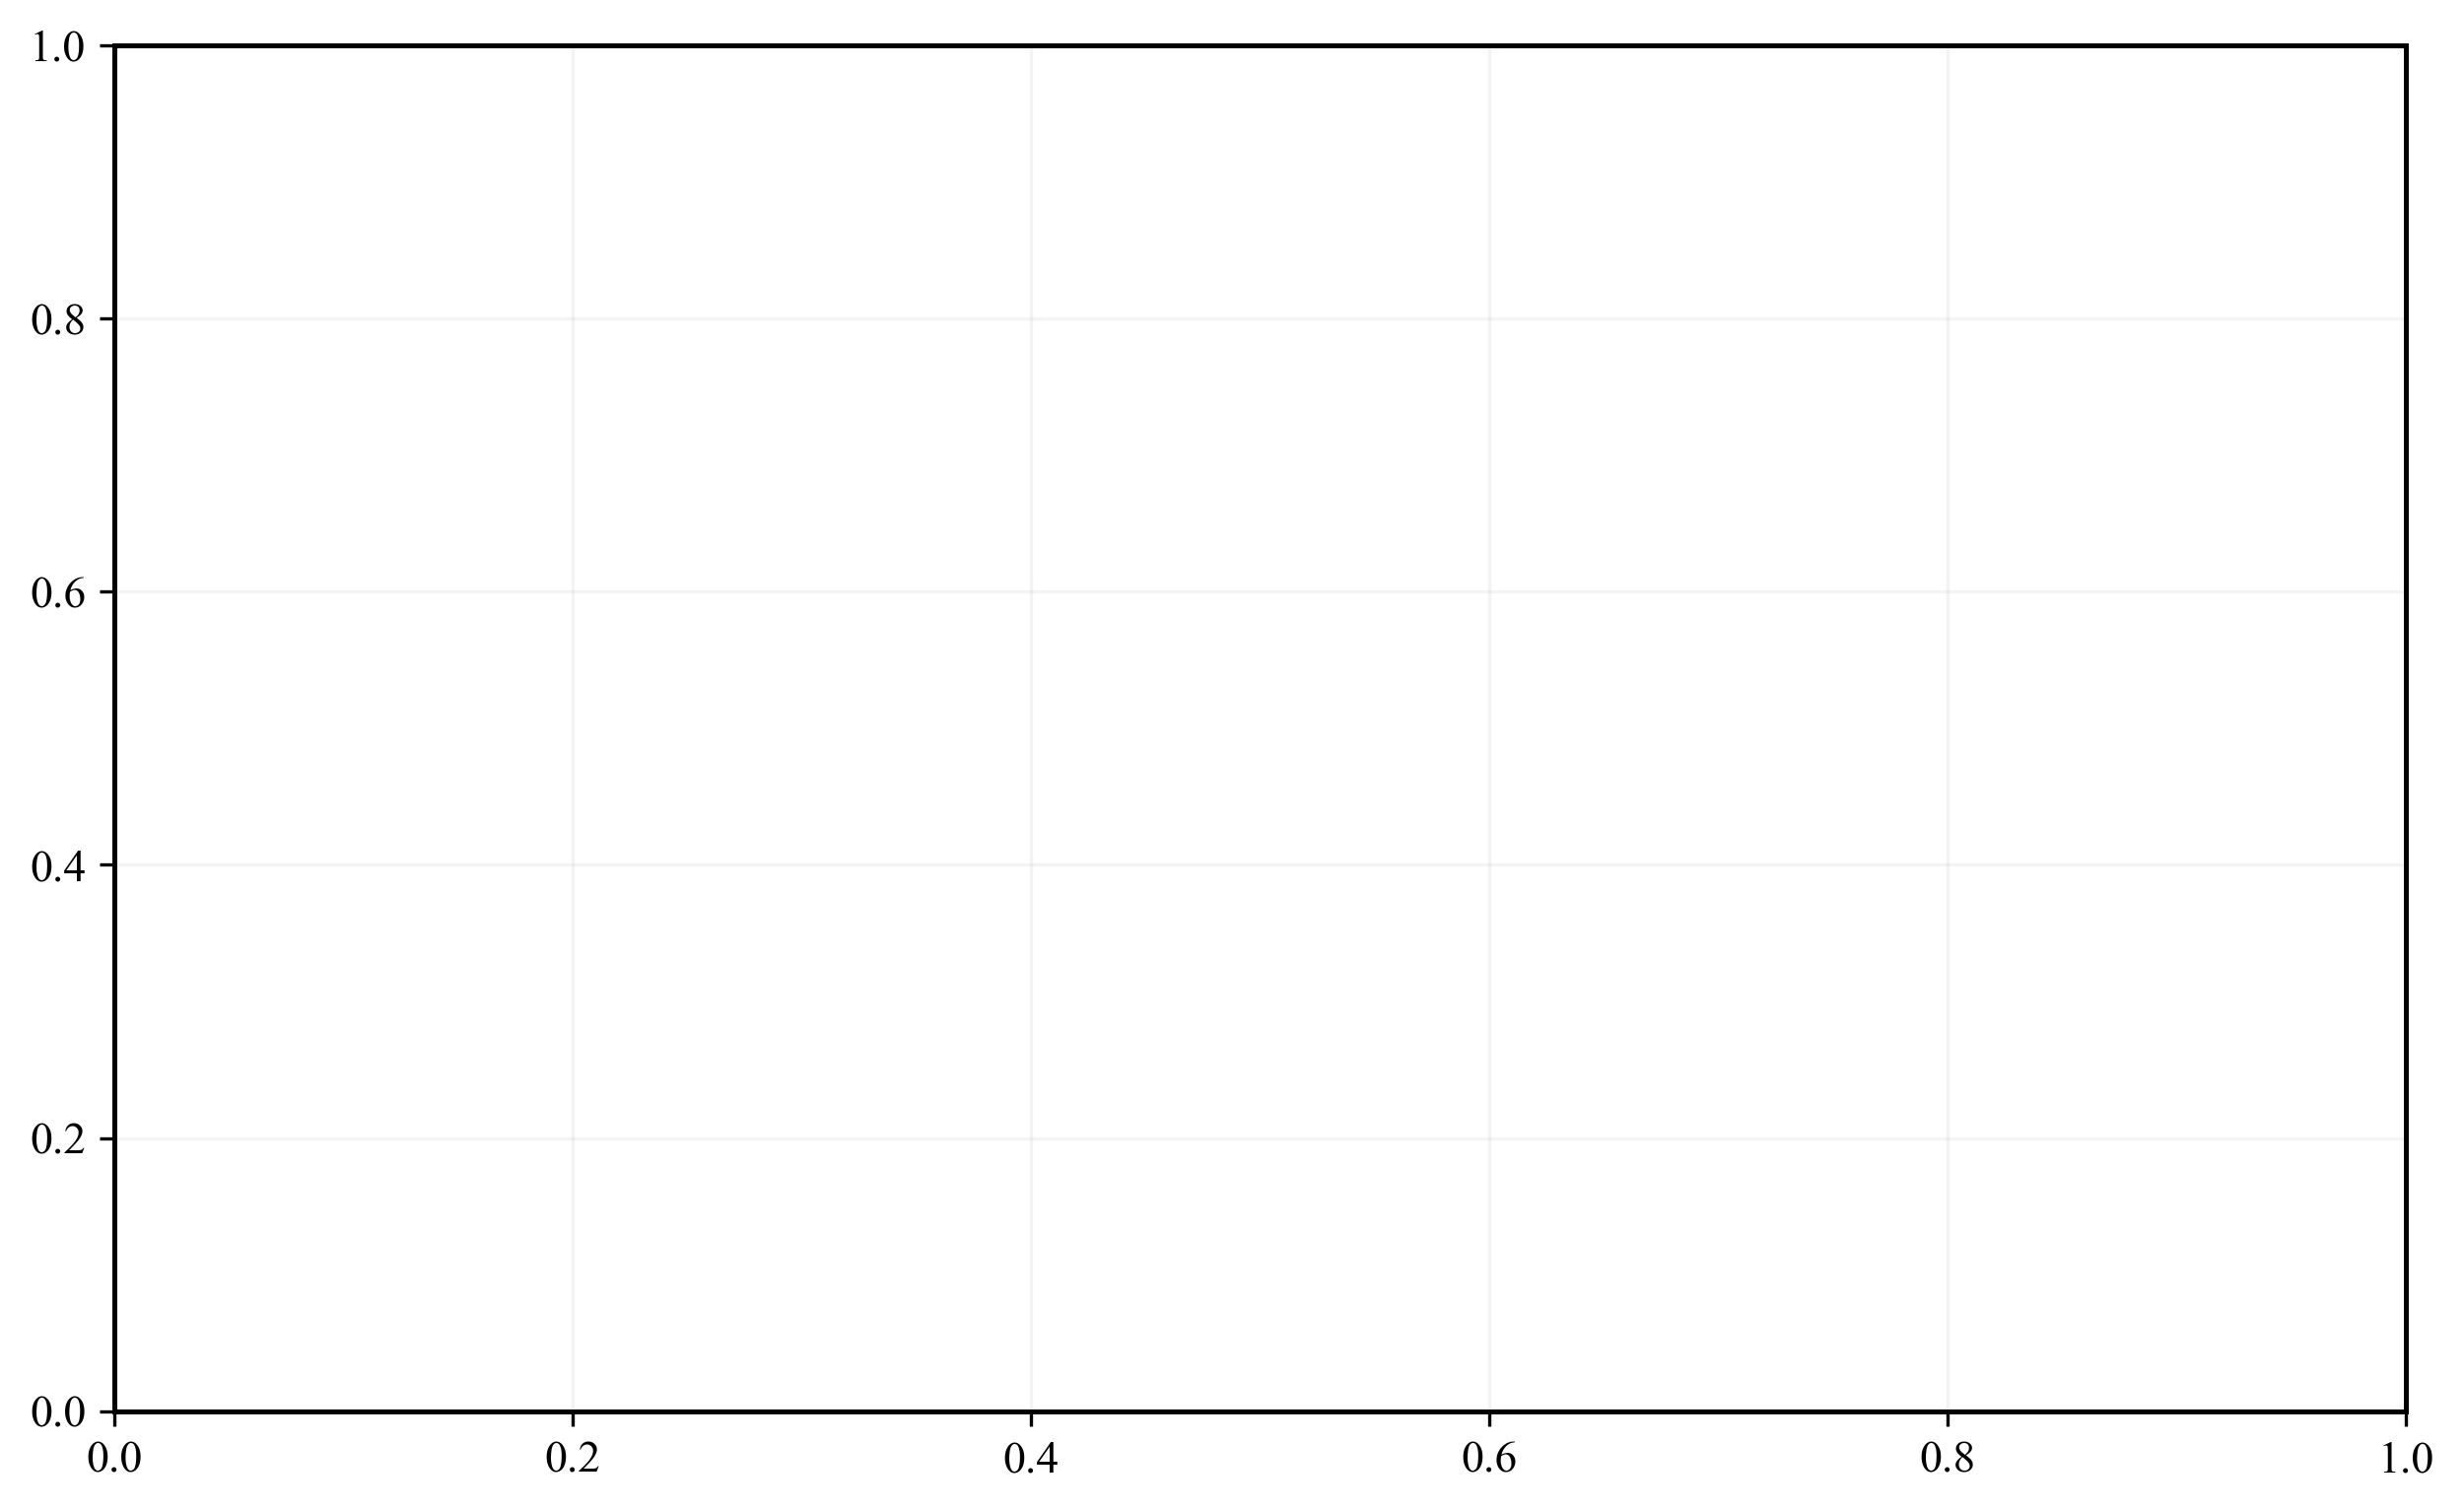

In [41]:


# ============================================================================
# EXAMPLE USAGE (uncomment if running directly)
# ============================================================================
ModelSet = 1
# plotter = SingleModelPlotter_Stacking(ModelSet=ModelSet)


# ============================================================================
# Example usage (uncomment after extraction function is defined)
# ============================================================================
_, _, stacking_viz_data = DataExtractionFrom_StackingEnsembleModernVisualizer_touseinMultiplePlots()
comparator = MultiModelStackingComparator(stacking_viz_data, results_path="./multi_stacking_comparison")
comparator.generate_all_comparisons()